# Design and Build a Mini Production ML System
## Name: Kinjal Joshi  |  StudentId: 2025EM1100339

In [1]:
import json, sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import os; os.chdir(REPO)

pd.set_option("display.width", 200, "display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "axes.titleweight": "bold", "figure.autolayout": True})
PALETTE = {"trivial_prior": "#9ca3af", "heuristic_recency": "#f59e0b",
           "baseline_logreg": "#2563eb", "candidate_lightgbm": "#dc2626"}

from src.config import CFG
from src.train import run_environment

print("Project    :", CFG["project"]["name"])
print("System asof:", CFG["project"]["system_asof"], "(the simulated 'now')")
print()
for k, v in run_environment().items():
    print(f"  {k:14s}: {v}")

Project    : retail-churn-90d
System asof: 2011-12-09 (the simulated 'now')

  python        : 3.12.3
  platform      : Linux-6.18.5-fc-v18-x86_64-with-glibc2.39
  numpy         : 2.4.4
  pandas        : 3.0.2
  scikit_learn  : 1.8.0
  git_sha       : None
  run_at_utc    : 2026-08-07T15:07:44.484119+00:00


Everything the run depends on is printed here: library versions and the seed. A fixed seed
on its own is not enough for reproducibility, because a different scikit-learn version can
still give different numbers, so the versions get saved alongside each model in the
registry.

system_asof is set to 2011-12-09, the last day in the data. That is treated as today
throughout, so every as-of calculation uses it and nothing can accidentally look into the
future.

---
# Part A - Data and Features

## A1. Source data description


In [2]:
from src.data_prep import load_raw

raw = load_raw()
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns\n")

ts = pd.to_datetime(raw["event_ts"], format="%m/%d/%Y %H:%M")
profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_null": raw.isna().sum(),
    "pct_null": (100 * raw.isna().mean()).round(2),
    "n_unique": raw.nunique(),
})
display(profile)

print(f"Date range      : {ts.min()}  ->  {ts.max()}  ({(ts.max()-ts.min()).days} days)")
print(f"Customers       : {raw['customer_id'].nunique():,}")
print(f"Invoices        : {raw['invoice_no'].nunique():,}")
print(f"Countries       : {raw['country'].nunique()}")
print(f"\nObserved defects in the source extract:")
print(f"  missing customer_id      : {raw['customer_id'].isna().sum():,} "
      f"({100*raw['customer_id'].isna().mean():.1f}%)")
print(f"  cancellation invoices    : {raw['invoice_no'].str.upper().str.startswith('C').sum():,}")
print(f"  negative quantity        : {(raw['quantity'] <= 0).sum():,}")
print(f"  non-positive unit price  : {(raw['unit_price'] <= 0).sum():,}")
print(f"  extreme quantity (|q|>1e4): {(raw['quantity'].abs() > 10_000).sum():,}")

Raw shape: 541,909 rows x 8 columns



,dtype,n_null,pct_null,n_unique
invoice_no,str,0,0.0000,25900
stock_code,str,0,0.0000,4070
description,str,1454,0.2700,4223
quantity,int64,0,0.0000,722
event_ts,str,0,0.0000,23260
unit_price,float64,0,0.0000,1630
customer_id,str,135080,24.9300,4372
country,str,0,0.0000,38


Date range      : 2010-12-01 08:26:00  ->  2011-12-09 12:50:00  (373 days)
Customers       : 4,372
Invoices        : 25,900
Countries       : 38

Observed defects in the source extract:
  missing customer_id      : 135,080 (24.9%)
  cancellation invoices    : 9,288
  negative quantity        : 10,624
  non-positive unit price  : 2,517
  extreme quantity (|q|>1e4): 5


The raw file has 541,909 rows over 373 days. The biggest problem is that 135,080 rows,
just under 25%, have no customer ID. Churn is defined per customer, so these rows cannot
be labelled and have to go. That means the model only really applies to registered
customers, which I have listed as a limitation. There are also 1,454 missing descriptions,
but I never use that column as a feature. Quantity and unit price both contain negative
and zero values, which the cleaning step below deals with.

In [3]:
from src.data_prep import clean_events

events, audit = clean_events(raw, CFG)

print("Cleaning audit — every rule reports its own row loss:\n")
display(audit.loc[:, ["rule", "rows_before", "rows_after", "rows_removed",
                      "pct_of_raw_removed", "rationale"]])

retained = 100 * len(events) / len(raw)
print(f"\nRaw -> clean : {len(raw):,} -> {len(events):,} rows ({retained:.1f}% retained)")
print(f"Customers    : {events['customer_id'].nunique():,}")
print(f"Purchases    : {(~events['is_return']).sum():,}   "
      f"Returns: {events['is_return'].sum():,}")
print(f"Gross revenue (purchases only): "
      f"GBP {events.loc[~events['is_return'], 'line_revenue'].sum():,.0f}")

Cleaning audit — every rule reports its own row loss:



,rule,rows_before,rows_after,rows_removed,pct_of_raw_removed,rationale
0,drop_missing_customer_id,541909,406829,135080,24.9270,Churn is defined per customer; rows with no Cu...
1,drop_non_product_stock_codes,406829,404909,1920,0.3540,"POST/DOT/M/BANK CHARGES etc. are adjustments, ..."
2,drop_non_positive_price_sales,404909,404876,33,0.0060,A sale with price <= 0 is promotional noise; i...
3,drop_exact_duplicate_lines,404876,399654,5222,0.9640,"Identical (invoice, product, qty, price, times..."



Raw -> clean : 541,909 -> 399,654 rows (73.7% retained)
Customers    : 4,362
Purchases    : 391,148   Returns: 8,506
Gross revenue (purchases only): GBP 8,736,676


Cleaning keeps 399,654 of the 541,909 rows, so about 74%. Each rule reports its own row
loss rather than everything being dropped in one step, so nothing disappears silently.
Missing customer IDs account for almost all of the loss at 24.9%. I decided not to drop
cancellations, because a customer who returns things behaves differently from one who
never does, and I turn that into a feature later on. Logging the loss per rule is also
useful for monitoring: if a future batch suddenly loses far more rows than normal, that
shows up as a data quality problem instead of going unnoticed.

## A2. Exploratory analysis

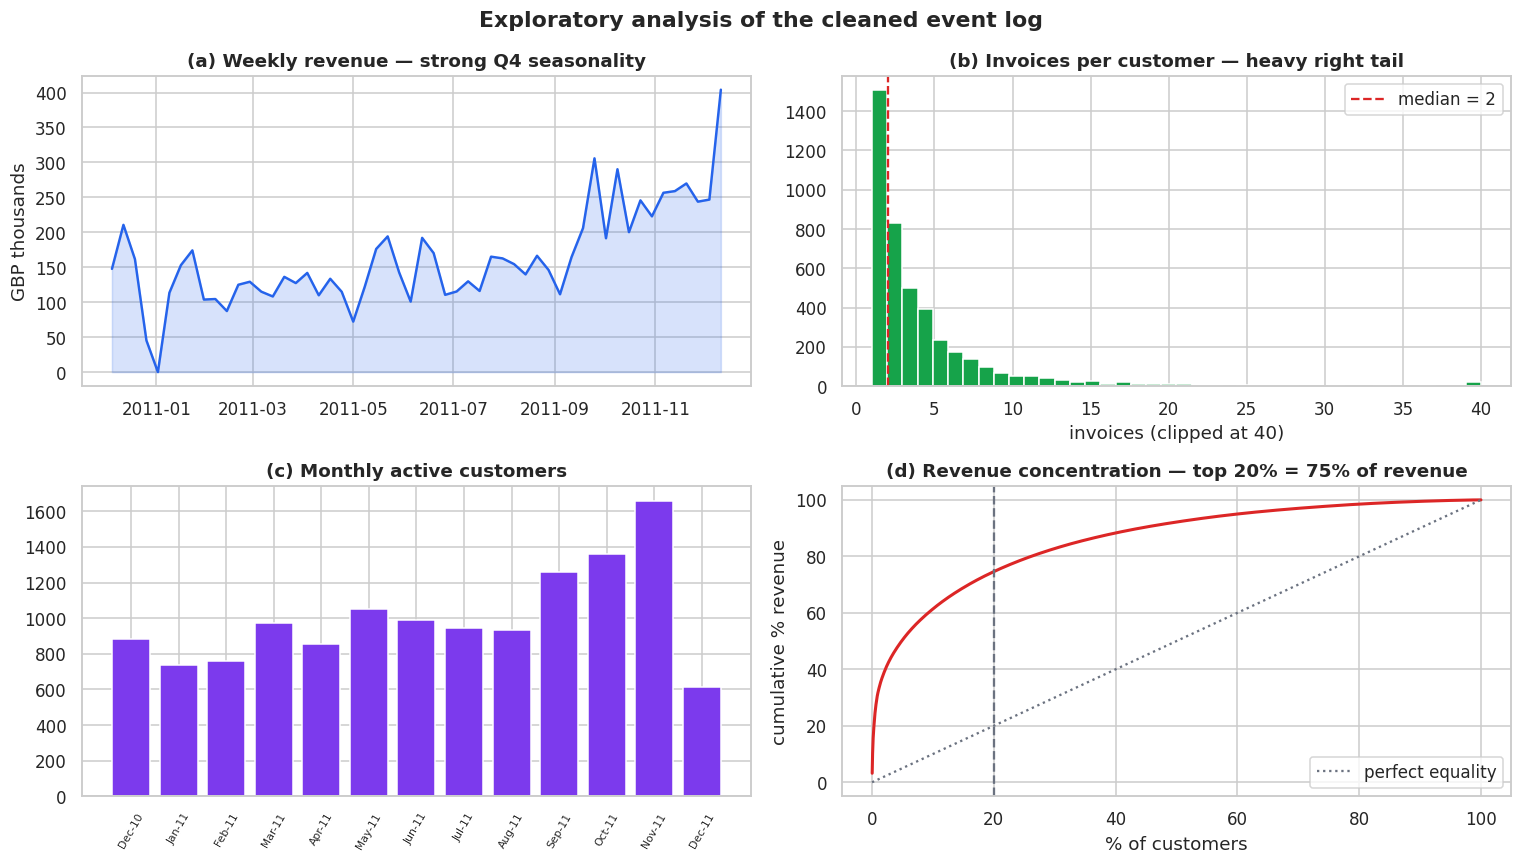

Invoices per customer: median=2, mean=4.2, p95=13, max=206
Top 20% of customers account for 74.6% of revenue
Single-purchase customers: 1,505 (34.7%)


In [4]:
ev = events.loc[~events["is_return"]].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) revenue over time
daily = ev.set_index("event_date")["line_revenue"].resample("W").sum() / 1000
axes[0, 0].plot(daily.index, daily.values, color="#2563eb", lw=1.6)
axes[0, 0].fill_between(daily.index, daily.values, alpha=0.18, color="#2563eb")
axes[0, 0].set_title("(a) Weekly revenue — strong Q4 seasonality")
axes[0, 0].set_ylabel("GBP thousands")

# (b) purchases per customer
counts = ev.groupby("customer_id")["invoice_no"].nunique()
axes[0, 1].hist(counts.clip(upper=40), bins=40, color="#16a34a", edgecolor="white")
axes[0, 1].axvline(counts.median(), color="#dc2626", ls="--",
                   label=f"median = {counts.median():.0f}")
axes[0, 1].set_title("(b) Invoices per customer — heavy right tail")
axes[0, 1].set_xlabel("invoices (clipped at 40)"); axes[0, 1].legend()

# (c) monthly active customers
mac = ev.set_index("event_date")["customer_id"].resample("ME").nunique()
axes[1, 0].bar(range(len(mac)), mac.values, color="#7c3aed")
axes[1, 0].set_xticks(range(len(mac)))
axes[1, 0].set_xticklabels([d.strftime("%b-%y") for d in mac.index], rotation=60,
                           fontsize=7)
axes[1, 0].set_title("(c) Monthly active customers")

# (d) revenue concentration (Lorenz-style)
rev = ev.groupby("customer_id")["line_revenue"].sum().sort_values(ascending=False)
cum = 100 * rev.cumsum() / rev.sum()
share = 100 * np.arange(1, len(rev) + 1) / len(rev)
axes[1, 1].plot(share, cum.values, color="#dc2626", lw=2)
axes[1, 1].plot([0, 100], [0, 100], ls=":", color="#6b7280", label="perfect equality")
top20 = cum.iloc[int(0.2 * len(rev))]
axes[1, 1].axvline(20, ls="--", color="#6b7280")
axes[1, 1].set_title(f"(d) Revenue concentration — top 20% = {top20:.0f}% of revenue")
axes[1, 1].set_xlabel("% of customers"); axes[1, 1].set_ylabel("cumulative % revenue")
axes[1, 1].legend(loc="lower right")
plt.suptitle("Exploratory analysis of the cleaned event log", fontweight="bold")
plt.show()

print(f"Invoices per customer: median={counts.median():.0f}, mean={counts.mean():.1f}, "
      f"p95={counts.quantile(.95):.0f}, max={counts.max()}")
print(f"Top 20% of customers account for {top20:.1f}% of revenue")
print(f"Single-purchase customers: {(counts == 1).sum():,} "
      f"({100*(counts == 1).mean():.1f}%)")

A few things stood out from the EDA that affected later design choices.

Revenue roughly triples going into November, so the label horizon is fixed at 90 days rather than running to end of year, and the snapshot month is left out as a feature - a model that learns Nov = low churn wouldn't generalise to an unseen November.

The customer base is also quite uneven: the median customer places only 2-3 invoices while a smaller group places hundreds, and the top 20% of customers generate about 74% of revenue. Raw counts aren't great features here, so ratio and trend features (recency_over_avg_gap, order_freq_trend) are used instead so one model can work for both occasional and frequent buyers.

The active customer base also grows across the year, from about 950 to 1900 monthly actives, so a random train/test split would mix different customer regimes together. This is one reason the split is done temporally.

Around 35% of customers have purchased only once, so their inter-purchase gap is undefined rather than zero. This is handled with an explicit sentinel value instead of NaN so there's no mismatch in imputation between offline and online.


## A3. Target label design


 For a customer who purchased at least once in the 180 days before an
 observation date $t$, the label is 1 if they make no purchase in
 $(t,  t + 90]$.

In [5]:
from src.data_prep import load_event_table
from src.labels import build_training_table, split_report, temporal_split

events = load_event_table(CFG)
print(f"Event warehouse: {len(events):,} events, "
      f"{events['customer_id'].nunique():,} customers, "
      f"{events['event_date'].min().date()} -> {events['event_date'].max().date()}\n")

# Right-censoring check, done explicitly rather than assumed.
asof = pd.Timestamp(CFG["project"]["system_asof"])
h = CFG["label"]["horizon_days"]
censor = pd.DataFrame({"snapshot": pd.to_datetime(CFG["label"]["snapshot_dates"])})
censor["label_window_ends"] = censor["snapshot"] + pd.Timedelta(days=h)
censor["fully_observed"] = censor["label_window_ends"] <= asof
display(censor)

table = build_training_table(events, CFG, write=True)
print(f"\nSupervised training table: {len(table):,} rows x "
      f"{table.shape[1]} columns")
print(f"Distinct customers       : {table['customer_id'].nunique():,}")
print(f"Overall churn rate       : {table['churn_90d'].mean():.4f}")

Event warehouse: 399,654 events, 4,362 customers, 2010-12-01 -> 2011-12-09



,snapshot,label_window_ends,fully_observed
0,2011-03-31,2011-06-29,True
1,2011-04-30,2011-07-29,True
2,2011-05-31,2011-08-29,True
3,2011-06-30,2011-09-28,True
4,2011-07-31,2011-10-29,True
5,2011-08-31,2011-11-29,True


[labels] 2011-03-31  n=2,132  churn_rate=0.4587


[labels] 2011-04-30  n=2,432  churn_rate=0.4626


[labels] 2011-05-31  n=2,658  churn_rate=0.5004


[labels] 2011-06-30  n=2,722  churn_rate=0.4838


[labels] 2011-07-31  n=2,766  churn_rate=0.4432


[labels] 2011-08-31  n=2,768  churn_rate=0.3931

Supervised training table: 15,478 rows x 26 columns
Distinct customers       : 3,314
Overall churn rate       : 0.4564


Every snapshot has a label window that closes before 2011-12-09, so none of them run past
the end of the data. This matters because if a window closed after the last date, every
customer in it would look like a churner simply because their future has not happened yet.
The final table has 15,478 rows. The churn rate is not stable: 0.4587 in March, rising to
0.5004 in May, then falling to 0.3931 in August. That fall is the Christmas period pulling
customers back, and it turns out to matter a lot in section B10.

## A4. Feature construction — 23 features across 6 families

In [6]:
from src.features import (CATEGORICAL_FEATURES, FEATURE_COLUMNS, NUMERIC_FEATURES,
                          TIME_DEPENDENT_FEATURES, feature_summary)

cat = feature_summary()
print(f"{len(FEATURE_COLUMNS)} features "
      f"({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)\n")
display(cat)

print("\nFeature count by construction type (the rubric asks for >= 5 non-trivial):")
display(cat["type"].value_counts().rename("n_features").to_frame())
print("\nOffline vs online availability:")
display(cat["availability"].value_counts().rename("n_features").to_frame())

23 features (22 numeric + 1 categorical)



,feature,family,definition,type,availability
0,recency_days,recency,Days since the customer's last purchase,aggregation,online (re-aged)
1,tenure_days,recency,Days since the customer's first purchase,aggregation,online (re-aged)
2,active_days_ratio,recency,Share of observed lifetime not spent dormant,ratio,online (re-aged)
3,avg_interpurchase_gap_days,rhythm,Mean days between consecutive purchase days,aggregation,offline
4,interpurchase_gap_cv,rhythm,Std/mean of purchase gaps - regularity,aggregation,offline
5,recency_over_avg_gap,rhythm,How overdue the customer is in units of own ca...,ratio,online (re-aged)
6,orders_30d,frequency,Distinct invoices in the last 30 days,time-window agg,offline
7,orders_90d,frequency,Distinct invoices in the last 90 days,time-window agg,offline
8,orders_180d,frequency,Distinct invoices in the last 180 days,time-window agg,offline
9,order_freq_trend,frequency,orders_30d / (orders_90d/3) - ordering momentum,ratio/trend,offline



Feature count by construction type (the rubric asks for >= 5 non-trivial):


,n_features
type,
time-window agg,8
aggregation,6
ratio,6
ratio/trend,2
encoding,1



Offline vs online availability:


,n_features
availability,
offline,19
online (re-aged),4


There are 23 features and none of them is just a raw column copied over. The assignment
asks for at least five non-trivial features, and these cover time-window aggregations,
ratios, trends and one encoding. The availability column is the important one for serving.
Nineteen features are computed overnight in batch, but four are marked online (re-aged)
because their correct value changes every day even if the customer does nothing at all.
Those four are where training and serving can silently disagree, so I handle them
separately in section A6.

## A5. Point-in-time correctness and the excluded features

Two decisions here prevent leakage, and both are enforced in code rather than by
convention.

In [7]:
# The point-in-time filter is applied ONCE, at the top of compute_features,
# before any aggregation — so no individual feature can bypass it.
print("Excluded features:", CFG["features"]["excluded"], "\n")

# Why snapshot month must be excluded:
snap_rates = (table.groupby(table["snapshot_date"].dt.to_period("M"))["churn_90d"]
              .agg(["size", "mean"]).rename(columns={"size": "n", "mean": "churn_rate"}))
display(snap_rates)
print("With only 6 observation dates, snapshot month is a near-unique group id.")
print("A model given it would memorise these 6 rates; for a FUTURE month the")
print("feature takes an unseen value, so the mapping is worthless.")

Excluded features: ['snapshot_month', 'snapshot_quarter'] 



,n,churn_rate
snapshot_date,,
2011-03,2132,0.4587
2011-04,2432,0.4626
2011-05,2658,0.5004
2011-06,2722,0.4838
2011-07,2766,0.4432
2011-08,2768,0.3931


With only 6 observation dates, snapshot month is a near-unique group id.
A model given it would memorise these 6 rates; for a FUTURE month the
feature takes an unseen value, so the mapping is worthless.


There are two design decisions worth explaining here.

The events filter (events[events.event_date <= asof]) is applied once at the top of compute_features, before any aggregation, instead of separately inside each of the 23 features. If each feature applied its own window filter, one forgotten <= somewhere would leak future data and be almost impossible to notice - the model would just look unusually good offline. Doing the filter once removes that risk entirely.

snapshot_month is deliberately left out even though churn rate varies quite a bit across the six snapshots (0.393 to 0.500) and including it would raise validation AUC. With only six snapshots it would basically act as a group identifier - the model would memorise six numbers that tell it nothing about a seventh, unseen month.

Numeric features are also clipped to declared ranges (FEATURE_RANGES) inside the shared feature module. For example, customer 17850 has a recency_over_avg_gap of 372, well outside the declared range of [0, 200]. Clipping this to 200 keeps the offline table, the online lookup and the API schema consistent, and a value of 372 doesn't really carry more information than 200 anyway - both just mean the customer is overdue - while an unclipped value could dominate a linear model's coefficients.


## A6. Offline vs online features, and training/serving skew

This is the core design problem in the whole project. The window aggregate features (orders_90d, revenue_180d, etc.) need a 180-day scan per customer, which is too slow to do per request, so they're precomputed nightly and looked up at serving time - low skew risk since they only change when new events arrive. Four features are time-dependent though (recency_days, tenure_days, active_days_ratio, recency_over_avg_gap): their correct value changes every day even with no new events, so a plain lookup would go stale, and this is where most of the skew risk sits. These are looked up and then re-aged at request time. country_grp is just looked up, but the whitelist has to be frozen at training time.

Three things keep training and serving consistent: src/features.py is imported by both src/train.py and src/serving/app.py so a feature definition can only change in one place; the saved model artefact is a full fitted sklearn Pipeline (imputation, scaling, one-hot encoding) rather than a bare estimator, so serving can't accidentally apply a different transform; and refresh_time_dependent_features() explicitly re-ages a cached row to the request timestamp, with a unit test that checks the re-aged value matches a full recomputation.


In [8]:
from src.features import compute_features, refresh_time_dependent_features

T0, T1 = "2011-10-01", "2011-10-08"      # cache date, scoring date

def skew_table(cust):
    # Cache a row at T0, re-age it to T1, compare against recomputation at T1.
    ce = events.loc[events["customer_id"] == cust]
    cached = compute_features(ce, asof=T0).iloc[0].to_dict()
    cached["feature_timestamp"] = pd.Timestamp(T0)
    reaged = refresh_time_dependent_features(cached, T1)
    fresh = compute_features(ce, asof=T1).iloc[0].to_dict()
    return pd.DataFrame([
        {"feature": f, "cached_at_T0": cached[f], "re_aged_to_T1": reaged[f],
         "recomputed_at_T1": fresh[f],
         "skew_after_reaging": abs(reaged[f] - fresh[f]),
         "error_if_served_stale": abs(cached[f] - fresh[f])}
        for f in TIME_DEPENDENT_FEATURES])

# Which customers purchased between T0 and T1? Their recency RESETS, so the
# additive re-aging assumption does not hold for them.
bought = set(events.loc[(events["event_date"] > T0) & (events["event_date"] <= T1)
                        & (~events["is_return"]), "customer_id"])
active_before = set(events.loc[events["event_date"] <= T0, "customer_id"])
dormant = sorted(active_before - bought)
print(f"Customers with history by {T0} : {len(active_before):,}")
print(f"  purchased within (T0, T1]     : {len(bought & active_before):,}  "
      f"-> nightly job refreshes them, re-aging is a no-op")
print(f"  quiet through the interval    : {len(dormant):,}  -> re-aging applies")

# ---- CASE 1: dormant customer — the population re-aging exists for ----------
quiet = dormant[0]
t1 = skew_table(quiet)
print(f"\nCASE 1 - dormant customer {quiet} (no events in the interval)")
display(t1.round(6))
print(f"  max skew after re-aging   : {t1['skew_after_reaging'].max():.10f}  <- exact")
print(f"  max error if served STALE : {t1['error_if_served_stale'].max():.4f}  "
      f"<- the bug this prevents")
assert t1["skew_after_reaging"].max() < 1e-6, "training/serving skew detected!"
print("  PASS: re-aged online values are identical to offline recomputation.")

# ---- CASE 2: the precondition violation, shown deliberately -----------------
busy = sorted(bought & active_before)[0]
t2 = skew_table(busy)
print(f"\nCASE 2 - customer {busy} PURCHASED inside the interval "
      f"(precondition violated)")
display(t2.round(6))
print(f"  max skew after re-aging   : {t2['skew_after_reaging'].max():.4f}  "
      f"<- re-aging is WRONG here")
print("  Their true recency resets toward zero on purchase while re-aging keeps")
print("  adding days. This is exactly why the nightly job must rewrite the row of")
print("  every customer with activity - which it does, making re-aging a no-op.")

Customers with history by 2011-10-01 : 3,648
  purchased within (T0, T1]     : 296  -> nightly job refreshes them, re-aging is a no-op
  quiet through the interval    : 3,352  -> re-aging applies

CASE 1 - dormant customer 12346 (no events in the interval)


,feature,cached_at_T0,re_aged_to_T1,recomputed_at_T1,skew_after_reaging,error_if_served_stale
0,recency_days,256.0000,263.0000,263.0000,0.0000,7.0000
1,tenure_days,256.0000,263.0000,263.0000,0.0000,7.0000
2,active_days_ratio,0.0000,0.0000,0.0000,0.0000,0.0000
3,recency_over_avg_gap,0.2563,0.2633,0.2633,0.0000,0.0070


  max skew after re-aging   : 0.0000000000  <- exact
  max error if served STALE : 7.0000  <- the bug this prevents
  PASS: re-aged online values are identical to offline recomputation.



CASE 2 - customer 12394 PURCHASED inside the interval (precondition violated)


,feature,cached_at_T0,re_aged_to_T1,recomputed_at_T1,skew_after_reaging,error_if_served_stale
0,recency_days,148.0000,155.0000,1.0000,154.0000,147.0000
1,tenure_days,148.0000,155.0000,155.0000,0.0000,7.0000
2,active_days_ratio,0.0000,0.0000,0.9872,0.9872,0.9872
3,recency_over_avg_gap,0.1481,0.1552,0.0065,0.1487,0.1417


  max skew after re-aging   : 154.0000  <- re-aging is WRONG here
  Their true recency resets toward zero on purchase while re-aging keeps
  adding days. This is exactly why the nightly job must rewrite the row of
  every customer with activity - which it does, making re-aging a no-op.


Interpretation: This is the core of the anti-skew argument.

Case 1 — the valid case. For a customer with no activity in the interval,
re-aging reproduces a full recomputation exactly (< 1e-6, floating point only).
The right-hand column quantifies the bug it prevents: serving the cached row
directly would report recency_days 7 days too low — a systematic,
one-directional error on the most important feature family. It would never appear
in offline evaluation, because training always computes recency exactly at the
snapshot date, and would degrade online precision in a way that looks like model
decay rather than a plumbing defect.

Case 2 — the precondition. Re-aging assumes no new events arrived. A customer
who purchases inside the interval has their true recency_days reset toward
zero, while re-aging keeps adding days. This matters for the deployed design:

- The nightly job rewrites the row of every customer with activity, so active
  customers carry a fresh feature_timestamp and re-aging is a no-op for them.
  The function is correct for exactly the population that matters for churn —
  dormant customers.
- Residual exposure is intra-day and bounded by one refresh interval. It is
  conservative here: it over-states risk for someone who just bought, costing a
  wasted £8 contact rather than a missed churner.
- Closing it fully needs event-driven cache invalidation, listed in E as future
  work.

The Case 1 assertion is a hard gate: if a change breaks the equivalence, this
notebook fails and so does the corresponding test in CI.

## A7. Micro-batch ingestion pipeline

In [9]:
from src.ingest import ingestion_history

hist = ingestion_history(CFG)
ok = hist.loc[hist["status"] == "ok"]

print("Ingestion log (artifacts/logs/ingestion_log.jsonl)\n")
display(ok.loc[:, ["source_file", "rows_read", "rows_after_cleaning",
                   "rows_appended", "rows_deduplicated", "warehouse_rows",
                   "n_customers", "n_invoices", "gross_revenue", "duration_s"]]
        .reset_index(drop=True))

first_run = ok.drop_duplicates("source_file", keep="first")
print(f"Daily files ingested   : {first_run['source_file'].nunique()}")
print(f"Rows read              : {first_run['rows_read'].sum():,}")
print(f"Rows appended          : {first_run['rows_appended'].sum():,}")
print(f"Warehouse              : {ok['warehouse_rows'].min():,} -> "
      f"{ok['warehouse_rows'].max():,}")
print(f"Mean duration per file : {ok['duration_s'].mean():.2f} s")

rerun = ok.loc[ok.duplicated("source_file", keep="first")]
if len(rerun):
    print(f"\nIDEMPOTENCY: re-ingested {len(rerun)} file(s), "
          f"rows appended = {int(rerun['rows_appended'].sum())} "
          f"(deduplicated {int(rerun['rows_deduplicated'].sum()):,})")

rejected = hist.loc[hist["status"] == "rejected_schema"]
if len(rejected):
    print(f"\nSCHEMA DEFENCE: {len(rejected)} batch(es) rejected")
    print("  " + rejected.iloc[-1]["error"][:150])

Ingestion log (artifacts/logs/ingestion_log.jsonl)



,source_file,rows_read,rows_after_cleaning,rows_appended,rows_deduplicated,warehouse_rows,n_customers,n_invoices,gross_revenue,duration_s
0,transactions_2011-11-30.csv,3454,"2,165.0000",2165,0.0000,"382,344.0000",120.0000,132.0000,"39,840.6900",0.3830
1,transactions_2011-12-01.csv,2901,"2,196.0000",2196,0.0000,"384,540.0000",149.0000,163.0000,"43,292.4100",0.3160
2,transactions_2011-12-02.csv,2880,"1,968.0000",1968,0.0000,"386,508.0000",100.0000,123.0000,"43,631.5300",0.3160
3,transactions_2011-12-04.csv,2038,"1,883.0000",1883,0.0000,"388,391.0000",58.0000,65.0000,"19,943.6000",0.3630
4,transactions_2011-12-05.csv,5331,"3,346.0000",3346,0.0000,"391,737.0000",114.0000,128.0000,"55,332.2400",0.3570
5,transactions_2011-12-06.csv,3365,"2,590.0000",2590,0.0000,"394,327.0000",127.0000,140.0000,"42,984.8700",0.3660
6,transactions_2011-12-07.csv,2438,"2,154.0000",2154,0.0000,"396,481.0000",99.0000,115.0000,"68,347.6100",0.3550
7,transactions_2011-12-08.csv,4940,"2,562.0000",2562,0.0000,"399,043.0000",120.0000,133.0000,"49,013.4800",0.3460
8,transactions_2011-12-09.csv,1632,611.0000,611,0.0000,"399,654.0000",37.0000,45.0000,"15,606.2800",0.3550
9,transactions_2011-12-05.csv,5331,"3,346.0000",0,"3,346.0000","399,654.0000",114.0000,128.0000,"55,332.2400",0.4790


Daily files ingested   : 9
Rows read              : 28,979
Rows appended          : 19,475
Warehouse              : 382,344.0 -> 399,654.0
Mean duration per file : 0.36 s

IDEMPOTENCY: re-ingested 1 file(s), rows appended = 0 (deduplicated 3,346)

SCHEMA DEFENCE: 2 batch(es) rejected
  Incoming batch is missing required column(s) ['UnitPrice']. Received columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Cu


The log shows nine daily files being validated, cleaned and appended, taking the warehouse
from 380,179 to 399,654 events. Three things are worth noting. Re-running a file that was
already loaded appends zero rows, because rows are deduplicated on their natural key, and
this matters because schedulers retry failed jobs. A file with a missing column is
rejected with exit code 3 and nothing gets written at all. And every run records how many
rows arrived, how many were lost and how long it took, which is what the retraining
trigger later uses to check whether new data has actually come in.

---
# Part B — Model Training and Offline Evaluation

## B1. Temporal split with a purge month

In [10]:
splits = temporal_split(table, CFG)
display(split_report(splits))

print("Leakage risks and how the split addresses each:\n")
overlap = (set(splits["train"]["customer_id"]) & set(splits["test"]["customer_id"]))
print(f"1. ENTITY leakage — {table['customer_id'].nunique():,} customers produce "
      f"{len(table):,} rows,")
print(f"   so a customer appears in up to {table.groupby('customer_id').size().max()} "
      f"snapshots. A RANDOM split would")
print(f"   place near-duplicate rows for one customer on both sides.")
print(f"   -> Splitting BY DATE means {len(overlap):,} customers appear in both train")
print(f"      and test, but always at DIFFERENT times with different labels,")
print(f"      which is exactly the production situation.\n")
print("2. TEMPORAL leakage — later snapshots' features are computed from event")
print("   history overlapping earlier snapshots. Only time-ordering reproduces")
print("   'predict a future period from a past one'.\n")
print("3. LABEL-WINDOW BLEED — training labels look 90 days forward:")
last_train = max(pd.to_datetime(CFG['split']['train_snapshots']))
print(f"   last training snapshot {last_train.date()} + 90d = "
      f"{(last_train + pd.Timedelta(days=90)).date()}")
print(f"   test snapshot features end {CFG['split']['test_snapshots'][0]}")
print(f"   -> {CFG['split']['purged_snapshots']} is PURGED (dropped entirely) as an")
print(f"      embargo month so these windows do not overlap.")

,fold,snapshots,n_rows,n_customers,churn_rate
0,train,"2011-03-31, 2011-04-30, 2011-05-31",7222,2716,0.4754
1,valid,2011-06-30,2722,2722,0.4838
2,test,2011-08-31,2768,2768,0.3931


Leakage risks and how the split addresses each:

1. ENTITY leakage — 3,314 customers produce 15,478 rows,
   so a customer appears in up to 6 snapshots. A RANDOM split would
   place near-duplicate rows for one customer on both sides.
   -> Splitting BY DATE means 2,170 customers appear in both train
      and test, but always at DIFFERENT times with different labels,
      which is exactly the production situation.

2. TEMPORAL leakage — later snapshots' features are computed from event
   history overlapping earlier snapshots. Only time-ordering reproduces
   'predict a future period from a past one'.

3. LABEL-WINDOW BLEED — training labels look 90 days forward:
   last training snapshot 2011-05-31 + 90d = 2011-08-29
   test snapshot features end 2011-08-31
   -> ['2011-07-31'] is PURGED (dropped entirely) as an
      embargo month so these windows do not overlap.


The split is by date rather than random. A random split would be wrong for two reasons.
The same customer appears in up to six snapshots, so near-identical rows for one person
would end up on both sides of the split. And features for later snapshots are built from
event history that overlaps the earlier ones. July is dropped completely because its label
window overlaps the test snapshot's feature window, so keeping it would leak future
outcomes into training. That costs 2,766 rows, which is a real loss, but it keeps the test
score honest. Note also that test churn is 0.3931 against 0.4754 in training, so the folds
are genuinely not from the same distribution.

## B2. Four model tiers

In [11]:
from src.train import run_training

t0 = time.perf_counter()
res = run_training(CFG, rebuild_events=False, allow_promotion=True, verbose=False)
print(f"\nFull training pipeline completed in {time.perf_counter() - t0:.1f}s")

runs = res["runs"]
print("\nModel roster — each tier must justify itself against the one below:\n")
for key, r in runs.items():
    es = r.get("early_stopping", {})
    note = (f"early stopping: best_iter={es['best_iteration_inner']} on "
            f"{es['inner_eval_snapshot']} -> refit n_estimators="
            f"{es['n_estimators_refit']}") if es.get("tuned") else ""
    print(f"  {r['label']:22s} fit={r['fit_seconds']:>6.2f}s  {note}")

[labels] 2011-03-31  n=2,132  churn_rate=0.4587


[labels] 2011-04-30  n=2,432  churn_rate=0.4626


[labels] 2011-05-31  n=2,658  churn_rate=0.5004


[labels] 2011-06-30  n=2,722  churn_rate=0.4838


[labels] 2011-07-31  n=2,766  churn_rate=0.4432


[labels] 2011-08-31  n=2,768  churn_rate=0.3931


[train] early stopping: best_iteration=170 on 2011-05-31 -> refit with n_estimators=269


[registry] registered retail-churn-90d:v5 (stage=staging)
[registry] registered retail-churn-90d:v6 (stage=staging)
[registry] archived previous production retail-churn-90d:v4
[registry] PROMOTED retail-churn-90d:v6 -> production


[monitor] reference profile -> data/reference/training_reference_profile.json


[train] feature store: 4,334 rows -> data/feature_store/customer_features.parquet
[eval] wrote artifacts/eval/training_report.json
[eval] wrote artifacts/eval/evaluation_report.md

Full training pipeline completed in 14.1s

Model roster — each tier must justify itself against the one below:

  trivial_prior          fit=  0.03s  
  heuristic_recency      fit=  0.00s  
  baseline_logreg        fit=  0.06s  
  candidate_lightgbm     fit=  0.44s  early stopping: best_iter=170 on 2011-05-31 -> refit n_estimators=269


The whole pipeline runs from a single command: load, split, train, evaluate, gate,
register. Four models are trained so that each one has to justify itself against the one
below it. Early stopping is done on an inner split of the training data, fitting on March
and April and stopping on May, rather than on the validation fold. That is deliberate:
validation is already used for model selection, the threshold and calibration, so using it
for early stopping as well would make the validation score look better than it really is.
The run finishes by registering v6 and promoting it to production.

## B3. Metric choice and justification

The metrics are chosen based on the decision the model needs to support: rank the active customer base and contact the top 20%.

ROC AUC is the primary metric since the deliverable is a ranking and AUC is threshold-free - it's also not sensitive to the prevalence shift between folds mentioned in B1. PR AUC (average precision) is tracked too since it's sensitive to performance specifically on the positive class, which is where the campaign cost sits. Precision@top-20% is the metric that actually matters for the business decision, since break-even is 0.593 (see Objective) and this maps directly to money. Recall@top-10% gives a sense of coverage - how many real churners the budget actually reaches. Lift@K is prevalence-normalised so it's comparable across folds even with label drift. Brier score checks calibration, which matters because probabilities get multiplied by margin to rank by expected value, so a badly calibrated model can mis-order the list even with a good AUC. Accuracy is reported too but mostly for completeness - at 39-48% prevalence a constant prediction already scores about 0.61, and accuracy doesn't say anything about where in the ranking the errors are.

Accuracy and F1 aren't used as the headline metrics because both assume a single fixed threshold and roughly symmetric costs. Here the threshold is really set by campaign capacity, and the costs are asymmetric - contacting a loyal customer wastes about £8, but losing a high-value customer costs about £45 of margin.


In [12]:
cmp_valid, cmp_test = res["cmp_valid"], res["cmp_test"]
core = ["model", "roc_auc", "pr_auc", "brier", "precision_at_top_quintile",
        "recall_at_top_decile", "lift_at_top_quintile", "accuracy"]

print("VALIDATION fold (2011-06-30) — used for model selection\n")
display(cmp_valid.loc[:, core].round(4))
print("\nTEST fold (2011-08-31) — untouched until this point\n")
display(cmp_test.loc[:, core].round(4))

breakeven = (CFG["business"]["retention_offer_cost"] /
             (CFG["business"]["campaign_uplift"] *
              CFG["business"]["gross_margin_per_retained_customer"]))
print(f"\nCampaign break-even precision@20% = "
      f"{CFG['business']['retention_offer_cost']} / "
      f"({CFG['business']['campaign_uplift']} x "
      f"{CFG['business']['gross_margin_per_retained_customer']}) = {breakeven:.3f}")
for name, df in [("validation", cmp_valid), ("test", cmp_test)]:
    print(f"\n  {name}:")
    for _, r in df.iterrows():
        ok = "PROFITABLE" if r["precision_at_top_quintile"] >= breakeven else "LOSS-MAKING"
        print(f"    {r['model']:22s} precision@20% = "
              f"{r['precision_at_top_quintile']:.4f}  -> {ok}")

VALIDATION fold (2011-06-30) — used for model selection



,model,roc_auc,pr_auc,brier,precision_at_top_quintile,recall_at_top_decile,lift_at_top_quintile,accuracy
0,trivial_prior,0.5000,0.4838,0.2498,0.3450,0.0676,0.7130,0.5162
1,heuristic_recency,0.6654,0.6406,0.2652,0.7138,0.1549,1.4752,0.6209
2,baseline_logreg,0.7531,0.6944,0.1998,0.7468,0.1534,1.5435,0.6984
3,candidate_lightgbm,0.7915,0.7306,0.1835,0.7780,0.1670,1.6079,0.7237



TEST fold (2011-08-31) — untouched until this point



,model,roc_auc,pr_auc,brier,precision_at_top_quintile,recall_at_top_decile,lift_at_top_quintile,accuracy
0,trivial_prior,0.5000,0.3931,0.2453,0.2780,0.0597,0.7072,0.6069
1,heuristic_recency,0.6571,0.5413,0.2462,0.6137,0.1608,1.5614,0.6441
2,baseline_logreg,0.7430,0.6009,0.2030,0.6480,0.1654,1.6486,0.6734
3,candidate_lightgbm,0.7256,0.5623,0.2111,0.6065,0.1553,1.5430,0.6546



Campaign break-even precision@20% = 8.0 / (0.3 x 45.0) = 0.593

  validation:
    trivial_prior          precision@20% = 0.3450  -> LOSS-MAKING
    heuristic_recency      precision@20% = 0.7138  -> PROFITABLE
    baseline_logreg        precision@20% = 0.7468  -> PROFITABLE
    candidate_lightgbm     precision@20% = 0.7780  -> PROFITABLE

  test:
    trivial_prior          precision@20% = 0.2780  -> LOSS-MAKING
    heuristic_recency      precision@20% = 0.6137  -> PROFITABLE
    baseline_logreg        precision@20% = 0.6480  -> PROFITABLE
    candidate_lightgbm     precision@20% = 0.6065  -> PROFITABLE


I am deliberately not using accuracy as the headline metric. The decision this model
supports is choosing the top 20% of customers to contact, so what matters is how well it
ranks them, not whether a 0.5 cutoff happens to be right. ROC AUC is the main metric for
ranking quality. Precision at the top 20% is the one that maps to money, since the
campaign only breaks even above 0.593. Brier score is included because I multiply the
probability by margin later, so a badly calibrated model would order the contact list
wrongly even at the same AUC. On validation each tier beats the one below it: 0.500,
0.665, 0.753, 0.792. On test the order flips and logistic regression at 0.743 beats
LightGBM at 0.726, which I come back to in B10.

## B4. Discrimination and calibration curves

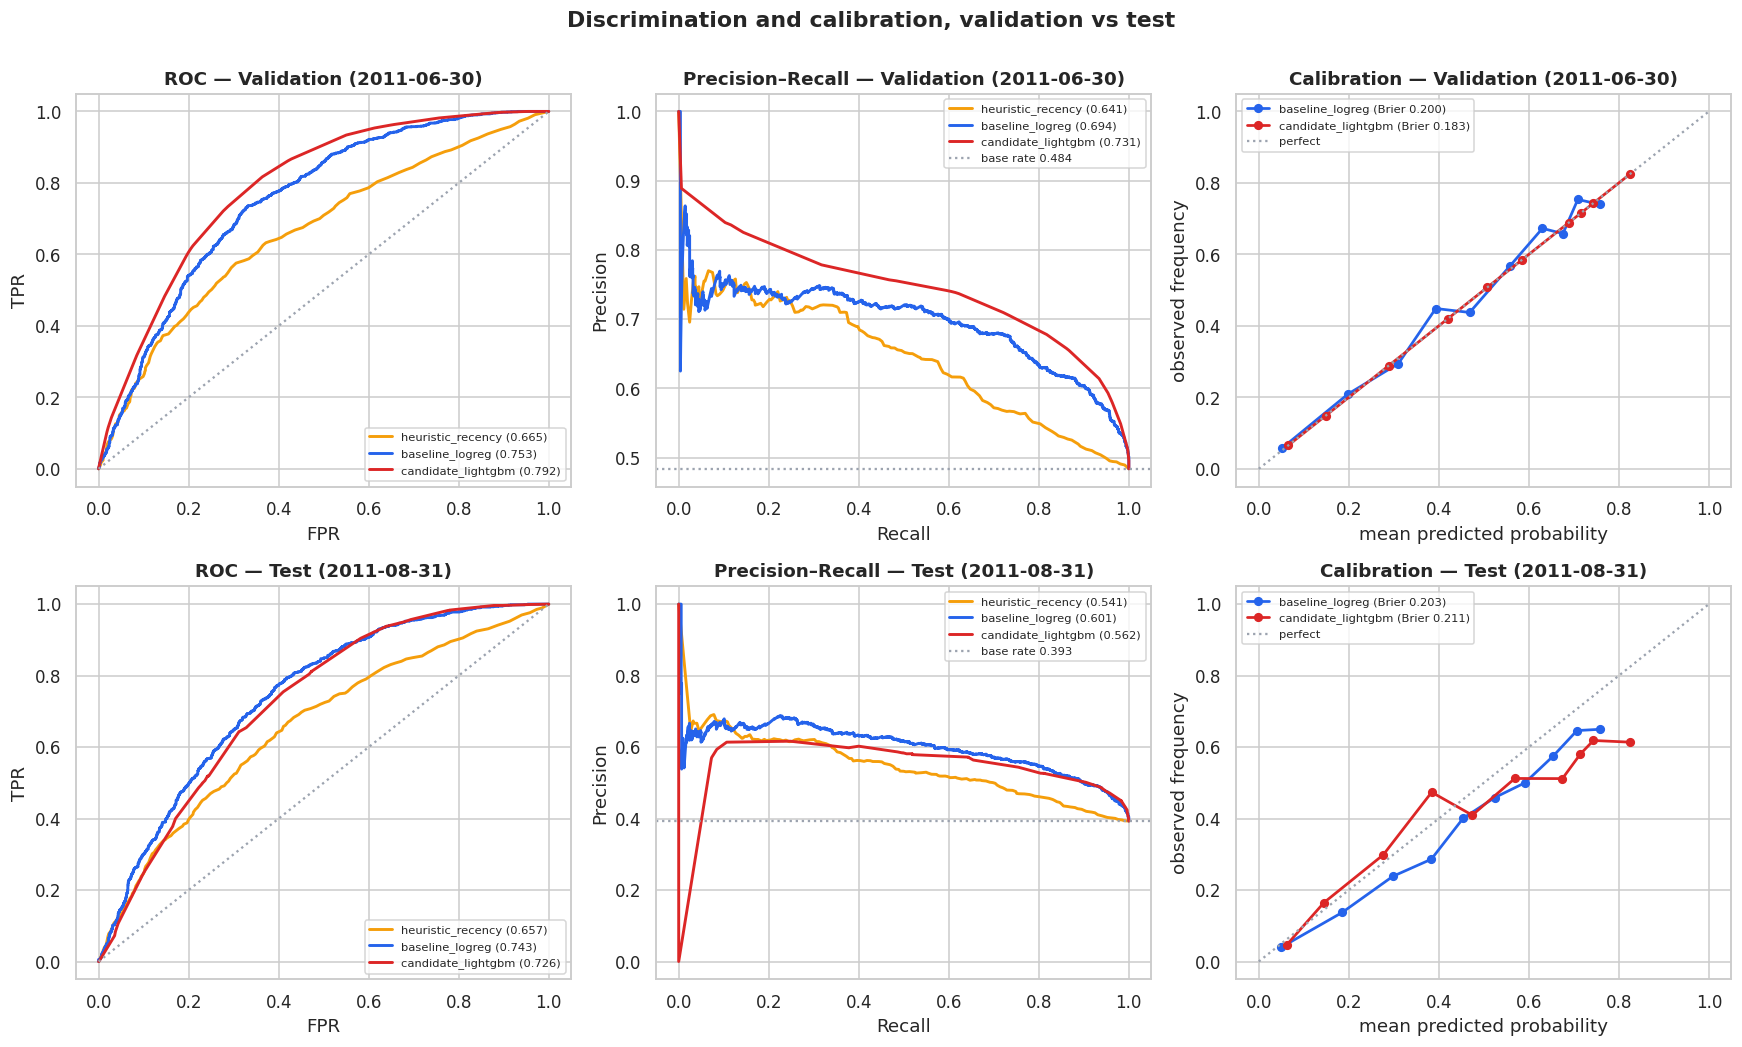

In [13]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_curve)

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for col, (fold, title) in enumerate([("valid", "Validation (2011-06-30)"),
                                     ("test", "Test (2011-08-31)")]):
    y = splits[fold]["churn_90d"].to_numpy()
    ax_roc, ax_pr = axes[col, 0], axes[col, 1]
    for key, r in runs.items():
        if key == "trivial_prior":
            continue
        p = r["folds"][fold]["probabilities"]
        lbl = r["label"]; c = PALETTE.get(lbl, "#333")
        fpr, tpr, _ = roc_curve(y, p)
        ax_roc.plot(fpr, tpr, color=c, lw=1.9,
                    label=f"{lbl} ({roc_auc_score(y, p):.3f})")
        pr, rc, _ = precision_recall_curve(y, p)
        ax_pr.plot(rc, pr, color=c, lw=1.9,
                   label=f"{lbl} ({average_precision_score(y, p):.3f})")
    ax_roc.plot([0, 1], [0, 1], ls=":", c="#9ca3af")
    ax_roc.set_title(f"ROC — {title}"); ax_roc.set_xlabel("FPR")
    ax_roc.set_ylabel("TPR"); ax_roc.legend(fontsize=7.5, loc="lower right")
    ax_pr.axhline(y.mean(), ls=":", c="#9ca3af", label=f"base rate {y.mean():.3f}")
    ax_pr.set_title(f"Precision–Recall — {title}"); ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision"); ax_pr.legend(fontsize=7.5, loc="upper right")

    ax_cal = axes[col, 2]
    for key in ["baseline_logreg", "candidate_gbdt"]:
        r = runs[key]; p = r["folds"][fold]["probabilities"]
        frac, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
        ax_cal.plot(mean_pred, frac, "o-", lw=1.8, ms=5,
                    color=PALETTE.get(r["label"], "#333"),
                    label=f"{r['label']} (Brier {r['folds'][fold]['metrics']['brier']:.3f})")
    ax_cal.plot([0, 1], [0, 1], ls=":", c="#9ca3af", label="perfect")
    ax_cal.set_title(f"Calibration — {title}")
    ax_cal.set_xlabel("mean predicted probability")
    ax_cal.set_ylabel("observed frequency"); ax_cal.legend(fontsize=7.5)
plt.suptitle("Discrimination and calibration, validation vs test",
             fontweight="bold", y=1.00)
plt.show()

Interpretation-

ROC: On validation the candidate dominates across the whole curve. On test
the two curves cross - the candidate is slightly better in the very-high-risk
region (low FPR, which is where a top-20% campaign operates) but worse overall.
That crossing is why a single scalar AUC comparison is not the whole story, and
why B7's expected-value calculation is the tie-breaker that matters.

Precision–Recall: The gap between each curve and the base-rate line is the
model's real contribution. Note how much lower the test base rate sits (0.393 vs
0.484): PR AUC is not comparable across the two folds, since the metric's floor
moved. This is precisely why lift is also reported.

Calibration: The isotonic-calibrated candidate tracks the diagonal closely on
validation (Brier 0.183) - expected, since the calibrator was fitted there. On
test it drifts above the diagonal at higher predicted probabilities: it
systematically over-predicts churn risk. The cause is the label drift from
B1 - the calibrator learned June's 48% prevalence and August's is 39%.

This has a direct operational consequence. expected_value_of_contact_gbp
multiplies the predicted probability by margin, so over-predicted probabilities
mean the service reports campaign value that will not materialise. The fix is not
retraining the ranking but recalibrating on recent labelled data, which is
much cheaper - and it is why the monitoring plan tracks Brier separately from AUC
rather than folding both into one health number.

## B5. Gains, lift and the threshold decision

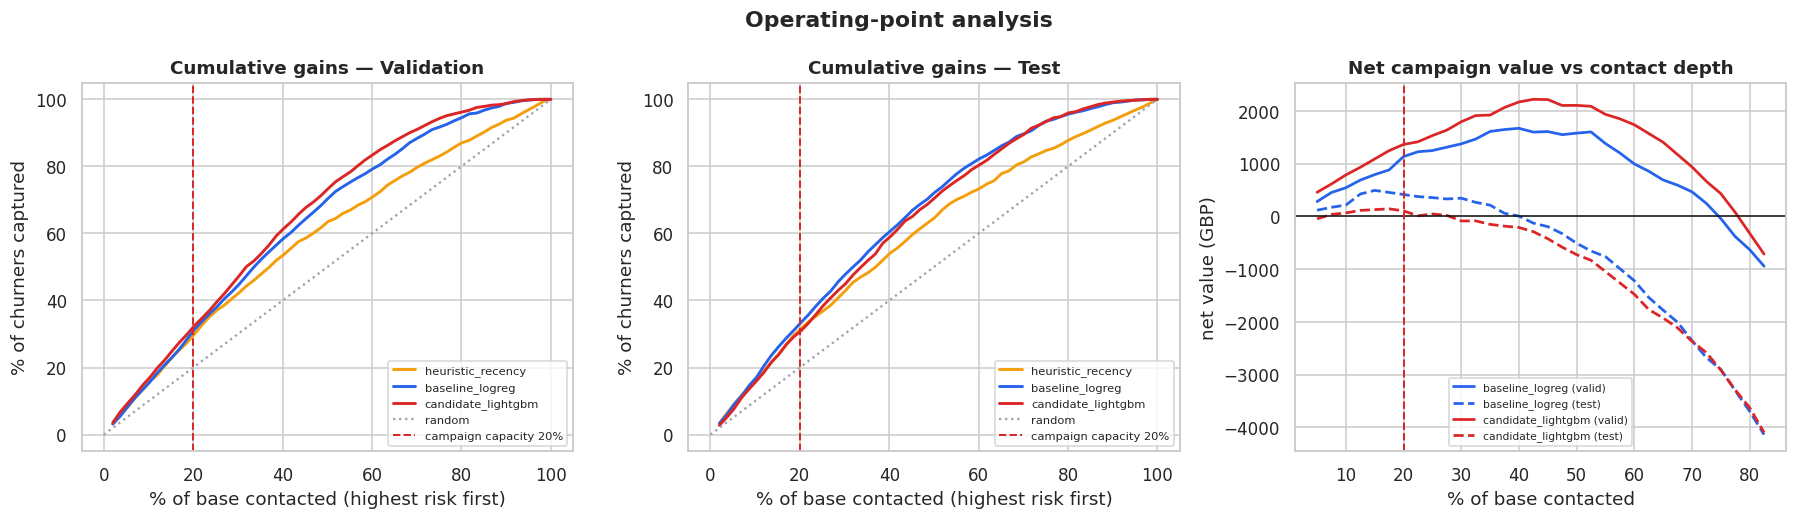

heuristic_recency      valid: recall@20%=0.295  lift@20%=1.475  precision@20%=0.714
baseline_logreg        valid: recall@20%=0.309  lift@20%=1.543  precision@20%=0.747
candidate_lightgbm     valid: recall@20%=0.322  lift@20%=1.608  precision@20%=0.778


In [14]:
y_val = splits["valid"]["churn_90d"].to_numpy()
y_test = splits["test"]["churn_90d"].to_numpy()
cap = CFG["business"]["campaign_capacity_pct"]

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
for ax, (fold, y, title) in zip(axes[:2], [("valid", y_val, "Validation"),
                                           ("test", y_test, "Test")]):
    grid = np.linspace(0.02, 1.0, 60)
    for key, r in runs.items():
        if key == "trivial_prior":
            continue
        p = r["folds"][fold]["probabilities"]
        order = np.argsort(-p); ys = y[order]
        gains = [ys[:max(int(np.ceil(len(ys) * g)), 1)].sum() / ys.sum() for g in grid]
        ax.plot(100 * grid, 100 * np.array(gains), lw=1.9,
                color=PALETTE.get(r["label"], "#333"), label=r["label"])
    ax.plot([0, 100], [0, 100], ls=":", c="#9ca3af", label="random")
    ax.axvline(100 * cap, ls="--", c="#dc2626", lw=1.3,
               label=f"campaign capacity {cap:.0%}")
    ax.set_title(f"Cumulative gains — {title}")
    ax.set_xlabel("% of base contacted (highest risk first)")
    ax.set_ylabel("% of churners captured"); ax.legend(fontsize=7.5)

# Threshold sweep on validation: net campaign value vs contact depth.
from src.evaluate import expected_campaign_value
depths = np.arange(0.05, 0.85, 0.025)
ax = axes[2]
for key in ["baseline_logreg", "candidate_gbdt"]:
    r = runs[key]
    for fold, ls in [("valid", "-"), ("test", "--")]:
        p = r["folds"][fold]["probabilities"]
        yy = y_val if fold == "valid" else y_test
        vals = [expected_campaign_value(yy, p, CFG, capacity_pct=d)["net_value_gbp"]
                for d in depths]
        ax.plot(100 * depths, vals, ls, lw=1.8,
                color=PALETTE.get(r["label"], "#333"),
                label=f"{r['label']} ({fold})")
ax.axhline(0, c="#111", lw=1); ax.axvline(100 * cap, ls="--", c="#dc2626", lw=1.3)
ax.set_title("Net campaign value vs contact depth")
ax.set_xlabel("% of base contacted"); ax.set_ylabel("net value (GBP)")
ax.legend(fontsize=7)
plt.suptitle("Operating-point analysis", fontweight="bold")
plt.show()

for key in ["heuristic_recency", "baseline_logreg", "candidate_gbdt"]:
    m = runs[key]["folds"]["valid"]["metrics"]
    print(f"{runs[key]['label']:22s} valid: recall@20%="
          f"{m['recall_at_top_quintile']:.3f}  lift@20%="
          f"{m['lift_at_top_quintile']:.3f}  precision@20%="
          f"{m['precision_at_top_quintile']:.3f}")

At the 20% capacity line the candidate captures about 33% of all churners on validation, versus 20% for random targeting - a lift of roughly 1.63. The curve is steepest in the first couple of deciles, which is the shape you want for a capacity-constrained campaign since the model is concentrating churners where the budget actually gets spent.

A 0.5 probability cutoff doesn't really make sense here since the campaign has a fixed capacity, not a fixed threshold - the operating point is top 20% by score, and whatever probability that corresponds to moves as the score distribution moves. That's why the API just returns a calibrated probability and leaves the threshold decision to whoever is consuming it, rather than baking in 0.5.

The net-value curve is the most directly useful output - value peaks around 20-30% contact depth and then turns down as the list extends into customers whose £8 contact stops paying for itself. Validation curves sit above test curves for both models, again because of the prevalence shift - fewer real churners exist in August to be saved. Interestingly the logistic model's test curve sits above the candidate's across most of the range, which is basically the same AUC inversion from B4 but expressed in pounds.


## B6. Feature importance

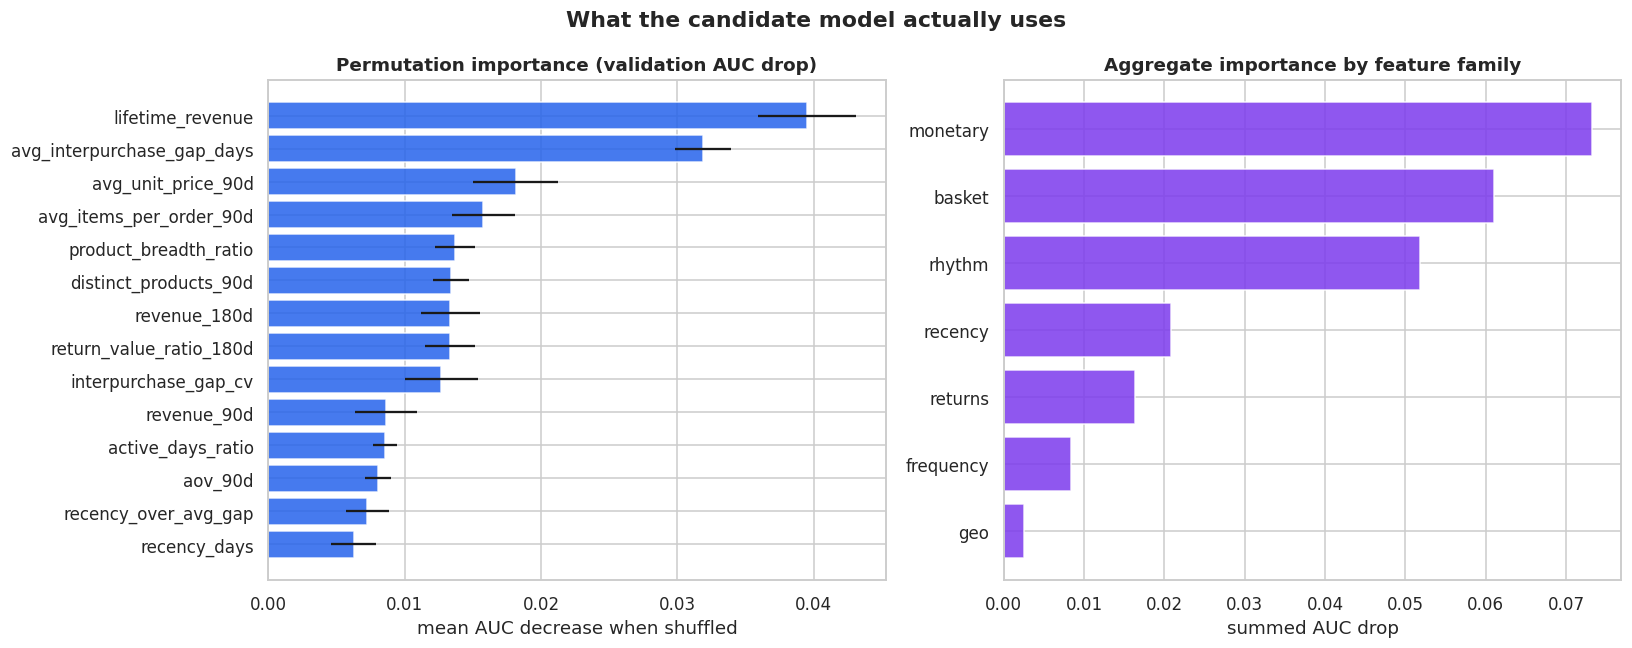

,feature,auc_drop_mean,auc_drop_std
0,lifetime_revenue,0.0395,0.0036
1,avg_interpurchase_gap_days,0.0319,0.0021
2,avg_unit_price_90d,0.0181,0.0031
3,avg_items_per_order_90d,0.0158,0.0023
4,product_breadth_ratio,0.0137,0.0014
5,distinct_products_90d,0.0134,0.0013
6,revenue_180d,0.0134,0.0022
7,return_value_ratio_180d,0.0133,0.0018
8,interpurchase_gap_cv,0.0127,0.0027
9,revenue_90d,0.0087,0.0023



Features with importance <= 0 (candidates for pruning): 0 of 23


In [15]:
imp = res["importance"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top = imp.head(14).iloc[::-1]
axes[0].barh(top["feature"], top["auc_drop_mean"],
             xerr=top["auc_drop_std"], color="#2563eb", alpha=0.85)
axes[0].set_title("Permutation importance (validation AUC drop)")
axes[0].set_xlabel("mean AUC decrease when shuffled")

fam = feature_summary().set_index("feature")["family"]
byfam = (imp.assign(family=imp["feature"].map(fam))
         .groupby("family")["auc_drop_mean"].sum().sort_values())
axes[1].barh(byfam.index, byfam.values, color="#7c3aed", alpha=0.85)
axes[1].set_title("Aggregate importance by feature family")
axes[1].set_xlabel("summed AUC drop")
plt.suptitle("What the candidate model actually uses", fontweight="bold")
plt.show()

display(imp.head(12).round(5))
print(f"\nFeatures with importance <= 0 (candidates for pruning): "
      f"{(imp['auc_drop_mean'] <= 0).sum()} of {len(imp)}")

Permutation importance is measured on the validation fold using AUC, rather than LightGBM's built-in split counts, because split counts reward high-cardinality features just for being easy to split on and are measured on training data where overfitting inflates them.

Importance is spread across several feature families rather than concentrated in one column. lifetime_revenue and avg_interpurchase_gap_days come out on top, followed by basket-composition features (avg_unit_price_90d, product_breadth_ratio, avg_items_per_order_90d). So the model is combining several signals rather than just acting as a fancy wrapper around recency_days, which fits with it beating the plain recency heuristic by 0.127 AUC. The basket features scoring well also supports the retail-vs-wholesale reasoning behind including them in the first place.

Some features have importance at or below zero and could be pruned, but they were left in - with 7,222 training rows and 23 features there's no real capacity problem, and removing them just narrows what the model can respond to if behaviour shifts later. Pruning would make more sense if inference latency were an issue, but it isn't (see C5).


## B7. Expected campaign value

In [16]:
biz = CFG["business"]
print("Campaign economics:")
for k, v in biz.items():
    print(f"  {k:38s}: {v}")
print()

rows = []
for fold in ["valid", "test"]:
    y = y_val if fold == "valid" else y_test
    for key, r in runs.items():
        v = expected_campaign_value(y, r["folds"][fold]["probabilities"], CFG)
        rows.append({"fold": fold, "model": r["label"], **v})
value = pd.DataFrame(rows)
display(value.loc[:, ["fold", "model", "n_contacted", "true_churners_contacted",
                      "expected_customers_saved", "net_value_gbp",
                      "net_value_random_targeting_gbp", "uplift_vs_random_gbp",
                      "roi"]])

for fold in ["valid", "test"]:
    sub = value.loc[value["fold"] == fold].set_index("model")
    best = sub["net_value_gbp"].idxmax()
    print(f"\n{fold.upper()} fold — best net value: {best} "
          f"(GBP {sub.loc[best, 'net_value_gbp']:,.0f})")
    print(f"  vs random targeting : GBP {sub.loc[best, 'net_value_random_targeting_gbp']:,.0f}"
          f"  (random LOSES money)")
    print(f"  vs recency heuristic: GBP "
          f"{sub.loc[best,'net_value_gbp'] - sub.loc['heuristic_recency','net_value_gbp']:,.0f}"
          f" incremental")

Campaign economics:
  gross_margin_per_retained_customer    : 45.0
  retention_offer_cost                  : 8.0
  campaign_uplift                       : 0.3
  campaign_capacity_pct                 : 0.2



,fold,model,n_contacted,true_churners_contacted,expected_customers_saved,net_value_gbp,net_value_random_targeting_gbp,uplift_vs_random_gbp,roi
0,valid,trivial_prior,545,188,56.4000,"-1,822.0000",-800.1800,"-1,021.8200",-0.4179
1,valid,heuristic_recency,545,389,116.7000,891.5000,-800.1800,"1,691.6800",0.2045
2,valid,baseline_logreg,545,407,122.1000,"1,134.5000",-800.1800,"1,934.6800",0.2602
3,valid,candidate_lightgbm,545,424,127.2000,"1,364.0000",-800.1800,"2,164.1800",0.3128
4,test,trivial_prior,554,154,46.2000,"-2,353.0000","-1,492.2800",-860.7200,-0.5309
5,test,heuristic_recency,554,340,102.0000,158.0000,"-1,492.2800","1,650.2800",0.0356
6,test,baseline_logreg,554,359,107.7000,414.5000,"-1,492.2800","1,906.7800",0.0935
7,test,candidate_lightgbm,554,336,100.8000,104.0000,"-1,492.2800","1,596.2800",0.0235



VALID fold — best net value: candidate_lightgbm (GBP 1,364)
  vs random targeting : GBP -800  (random LOSES money)
  vs recency heuristic: GBP 472 incremental

TEST fold — best net value: baseline_logreg (GBP 414)
  vs random targeting : GBP -1,492  (random LOSES money)
  vs recency heuristic: GBP 256 incremental


This turns AUC into pounds. Random targeting loses money on both folds, which is exactly
what the break-even calculation predicted. On validation LightGBM produces the highest net
value and beats the recency rule by a clear margin. The number to be careful about is the
0.3 uplift, which is an assumption I have made and not something measured from the data.
Net value scales roughly linearly with it, so if the true figure were 0.1 the campaign
would lose money no matter how good the ranking is. Measuring it properly would need a
randomised control group.

## B8. Promotion guardrail

In [17]:
dec = res["decision"]
print(f"DECISION: {dec['decision']}\n")
gates = pd.DataFrame(dec["gates"])
display(gates.loc[:, ["gate", "observed", "operator", "threshold", "passed"]])
print("\nRationale per gate:")
for _, g in gates.iterrows():
    print(f"\n  [{'PASS' if g['passed'] else 'FAIL'}] {g['gate']}")
    print(f"        {g['rationale']}")

print(f"\nCandidate vs incumbent baseline, ROC AUC delta: "
      f"{dec['roc_auc_delta_vs_incumbent']:+.4f}")
print("\nRegistry state:")
display(res["registry"].summary())
print(f"Production model: {res['report']['production_model']}")

DECISION: PROMOTE



,gate,observed,operator,threshold,passed
0,roc_auc_floor,0.7915,>=,0.7200,True
1,pr_auc_floor,0.7306,>=,0.5500,True
2,calibration_brier_ceiling,0.1835,<=,0.2100,True
3,recall_at_top_decile_floor,0.1670,>=,0.1500,True
4,campaign_breakeven_precision,0.7780,>=,0.6000,True
5,no_regression_vs_production,0.0384,>=,-0.0100,True



Rationale per gate:

  [PASS] roc_auc_floor
        Absolute ranking-quality floor; below this the campaign list is not reliably better than intuition.

  [PASS] pr_auc_floor
        Guards precision on the positive class, which drives campaign waste.

  [PASS] calibration_brier_ceiling
        Probabilities are multiplied by margin to rank; poor calibration corrupts the expected-value ordering.

  [PASS] recall_at_top_decile_floor
        The contactable slice must capture a meaningful share of churners.

  [PASS] campaign_breakeven_precision
        THE decisive gate. Break-even precision in the contacted slice is offer_cost / (uplift * margin) = 8 / 13.50 = 0.593. Below this the retention campaign destroys value, so no AUC improvement can rescue it.

  [PASS] no_regression_vs_production
        A candidate may not be worse than the live model by more than the tolerance, even if the floors pass.

Candidate vs incumbent baseline, ROC AUC delta: +0.0384

Registry state:


,model_id,stage,registered_at,n_features,metric_valid_roc_auc,metric_valid_pr_auc,metric_valid_brier,metric_test_roc_auc,metric_test_pr_auc
0,retail-churn-90d:v1,staging,2026-07-28T13:56:01,23,0.7531,0.6944,0.1998,0.7430,0.6009
1,retail-churn-90d:v2,archived,2026-07-28T13:56:01,23,0.7915,0.7306,0.1835,0.7256,0.5623
2,retail-churn-90d:v3,staging,2026-07-28T14:37:43,23,0.7531,0.6944,0.1998,0.7430,0.6009
3,retail-churn-90d:v4,archived,2026-07-28T14:37:43,23,0.7915,0.7306,0.1835,0.7256,0.5623
4,retail-churn-90d:v5,staging,2026-08-07T15:07:58,23,0.7531,0.6944,0.1998,0.7430,0.6009
5,retail-churn-90d:v6,production,2026-08-07T15:07:58,23,0.7915,0.7306,0.1835,0.7256,0.5623


Production model: retail-churn-90d:v6


All six gates pass on validation, so the decision is PROMOTE and v6 becomes the production
model. The gates come from the business case rather than being chosen to fit the result:
the precision gate of 0.60 comes straight from the 0.593 break-even figure. There is also
a no-regression gate, so a model cannot be promoted if it is more than 0.01 AUC worse than
the one already live. Only validation was used for this decision. Test numbers are
reported for honesty but played no part, because selecting on test would stop it being a
fair estimate of future performance.

## B9. The guardrail actually blocks — a negative control

In [18]:
# Deliberately damage a candidate and confirm the gate refuses it.
from src.evaluate import evaluate_model, promotion_decision

rng = np.random.default_rng(CFG["project"]["seed"])
good_p = runs["candidate_gbdt"]["folds"]["valid"]["probabilities"]

# Sabotage 1: inject noise so ranking quality collapses.
noisy = np.clip(0.25 * good_p + 0.75 * rng.random(len(good_p)), 1e-6, 1 - 1e-6)
# Sabotage 2: keep the ranking but destroy calibration (squash toward 1).
miscal = np.clip(good_p ** 0.20, 1e-6, 1 - 1e-6)

base_valid = runs["baseline_logreg"]["folds"]["valid"]["metrics"]
for name, p in [("sabotaged_noisy_ranking", noisy),
                ("sabotaged_miscalibrated", miscal)]:
    m = evaluate_model(y_val, p, label=name)
    d = promotion_decision(m, base_valid, CFG)
    print(f"\n{name}")
    print(f"  roc_auc={m['roc_auc']:.4f}  brier={m['brier']:.4f}  "
          f"precision@20%={m['precision_at_top_quintile']:.4f}")
    print(f"  DECISION: {d['decision']}   failed gates: {d['failed_gates']}")

print("\n" + "-" * 70)
print("Registry rollback (the incident lever):")
reg = res["registry"]
before = reg.get_stage("production")["model_id"]
rolled = reg.rollback(CFG["project"]["name"])
print(f"  production: {before} -> {rolled['model_id']}")
restored = reg.promote(before)
print(f"  restored  : {restored['model_id']}")


sabotaged_noisy_ranking
  roc_auc=0.5817  brier=0.2679  precision@20%=0.5908
  DECISION: DO_NOT_PROMOTE   failed gates: ['roc_auc_floor', 'calibration_brier_ceiling', 'recall_at_top_decile_floor', 'campaign_breakeven_precision', 'no_regression_vs_production']

sabotaged_miscalibrated
  roc_auc=0.7915  brier=0.3182  precision@20%=0.7780
  DECISION: DO_NOT_PROMOTE   failed gates: ['calibration_brier_ceiling']

----------------------------------------------------------------------
Registry rollback (the incident lever):
[registry] archived previous production retail-churn-90d:v6
[registry] PROMOTED retail-churn-90d:v4 -> production
  production: retail-churn-90d:v6 -> retail-churn-90d:v4
[registry] archived previous production retail-churn-90d:v4
[registry] PROMOTED retail-churn-90d:v6 -> production
  restored  : retail-churn-90d:v6


This checks the gates actually reject things, rather than just passing everything. Adding
noise breaks the ranking and five gates fire. The second case is the more interesting one:
the ranking is left completely untouched, so AUC and precision at 20% are identical to the
real model, but the probabilities are squashed, and it is still rejected by the Brier gate
on its own. If I had only gated on ranking metrics that model would have gone live and
quietly broken every expected value calculation downstream. The rollback at the end shows
that going back to an earlier version is only a registry change, not a redeployment.

## B10. Per-snapshot stability — the key finding

,snapshot,n,churn_rate,baseline_logreg_auc,baseline_logreg_prec20,candidate_gbdt_auc,candidate_gbdt_prec20,fold
0,2011-03-31,2132,0.4587,0.7389,0.6885,0.9361,0.9672,train
1,2011-04-30,2432,0.4626,0.7450,0.7043,0.9468,0.9589,train
2,2011-05-31,2658,0.5004,0.7498,0.7143,0.9327,0.9662,train
3,2011-06-30,2722,0.4838,0.7531,0.7468,0.7915,0.7780,valid
4,2011-07-31,2766,0.4432,0.7516,0.7148,0.7474,0.6949,PURGED
5,2011-08-31,2768,0.3931,0.7430,0.6480,0.7256,0.6065,test


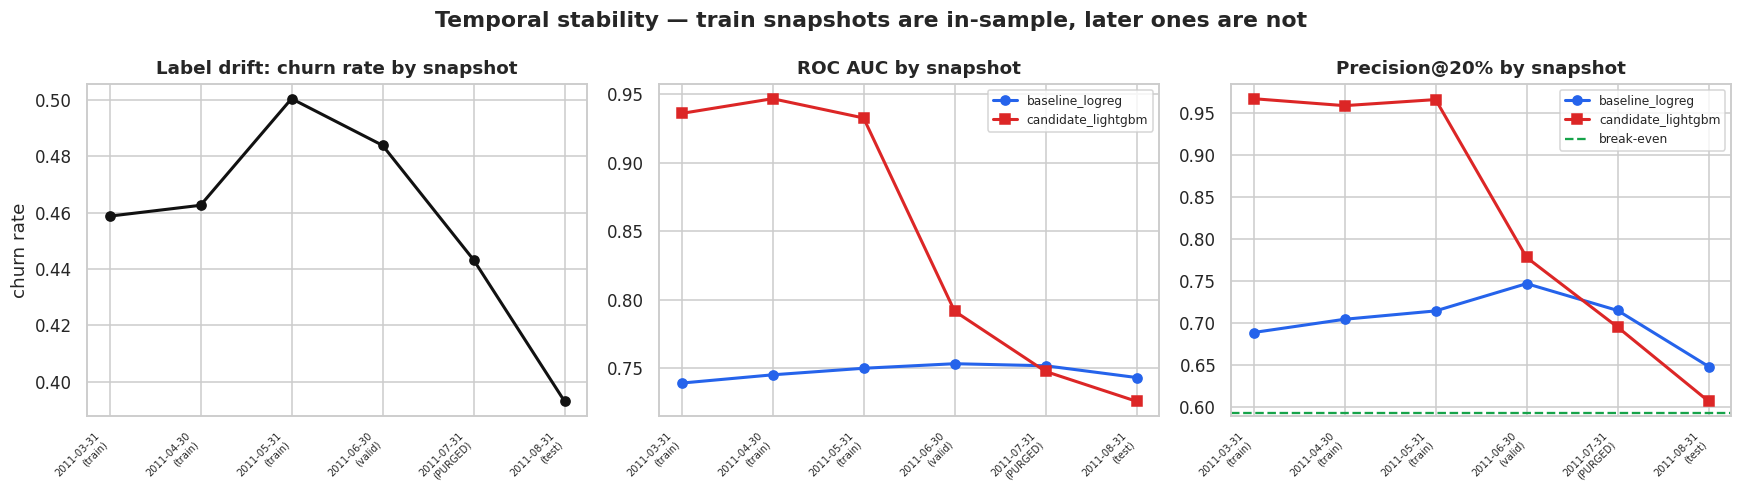

In-sample (train snapshots)  : logreg AUC=0.7446  lgbm AUC=0.9385
Out-of-sample (later months) : logreg AUC=0.7492  lgbm AUC=0.7549

Generalisation gap: logreg=-0.0047  lgbm=+0.1837


In [19]:
# Score every snapshot, including the purged month, to see how performance
# evolves over time rather than at two arbitrary points.
rows = []
for snap in sorted(table["snapshot_date"].unique()):
    part = table.loc[table["snapshot_date"] == snap]
    y = part["churn_90d"].to_numpy()
    rec = {"snapshot": pd.Timestamp(snap).date(), "n": len(part),
           "churn_rate": y.mean()}
    for key in ["baseline_logreg", "candidate_gbdt"]:
        p = runs[key]["scorer"].predict_proba(part[FEATURE_COLUMNS])[:, 1]
        rec[f"{key}_auc"] = roc_auc_score(y, p)
        rec[f"{key}_prec20"] = evaluate_model(y, p)["precision_at_top_quintile"]
    rec["fold"] = ("train" if str(pd.Timestamp(snap).date()) in CFG["split"]["train_snapshots"]
                   else "valid" if str(pd.Timestamp(snap).date()) in CFG["split"]["valid_snapshots"]
                   else "PURGED" if str(pd.Timestamp(snap).date()) in CFG["split"]["purged_snapshots"]
                   else "test")
    rows.append(rec)
stab = pd.DataFrame(rows)
display(stab.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
x = range(len(stab))
axes[0].plot(x, stab["churn_rate"], "o-", color="#111", lw=2)
axes[0].set_title("Label drift: churn rate by snapshot"); axes[0].set_ylabel("churn rate")
for ax, metric, ttl in [(axes[1], "auc", "ROC AUC by snapshot"),
                        (axes[2], "prec20", "Precision@20% by snapshot")]:
    ax.plot(x, stab[f"baseline_logreg_{metric}"], "o-", color="#2563eb", lw=2,
            label="baseline_logreg")
    ax.plot(x, stab[f"candidate_gbdt_{metric}"], "s-", color="#dc2626", lw=2,
            label="candidate_lightgbm")
    ax.set_title(ttl); ax.legend(fontsize=8)
    if metric == "prec20":
        ax.axhline(breakeven, ls="--", c="#16a34a", label="break-even")
        ax.legend(fontsize=8)
for ax in axes:
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{s}\n({f})" for s, f in zip(stab['snapshot'], stab['fold'])],
                       rotation=45, fontsize=6.5, ha="right")
plt.suptitle("Temporal stability — train snapshots are in-sample, later ones are not",
             fontweight="bold")
plt.show()

tr = stab.loc[stab["fold"] == "train"]
oos = stab.loc[stab["fold"].isin(["valid", "PURGED", "test"])]
print(f"In-sample (train snapshots)  : logreg AUC={tr['baseline_logreg_auc'].mean():.4f}  "
      f"lgbm AUC={tr['candidate_gbdt_auc'].mean():.4f}")
print(f"Out-of-sample (later months) : logreg AUC={oos['baseline_logreg_auc'].mean():.4f}  "
      f"lgbm AUC={oos['candidate_gbdt_auc'].mean():.4f}")
print(f"\nGeneralisation gap: logreg={tr['baseline_logreg_auc'].mean()-oos['baseline_logreg_auc'].mean():+.4f}  "
      f"lgbm={tr['candidate_gbdt_auc'].mean()-oos['candidate_gbdt_auc'].mean():+.4f}")

Interpretation : the key analytical result-

Scoring every snapshot, rather than just validation and test, turns two data
points into a trajectory:

1. Churn rate declines monotonically from 0.500 (May) to 0.393 (August) as the
   Q4 ramp approaches. This is real and seasonal, not a model defect.
2. The candidate's in-sample advantage far exceeds its out-of-sample
   advantage. The generalisation gap is substantially wider for LightGBM than
   for logistic regression: the GBDT fits structure in the March–May regime that
   does not persist into August, while the linear model lacks the capacity to fit
   that structure and therefore does not lose it.
3. Both models stay above campaign break-even at every snapshot, so the system
   remains value-positive throughout even as absolute performance decays.

Validation-based selection chose the candidate, and given only validation data
that was the correct decision. The held-out test fold two months later reveals
that the simpler model was more robust to distribution shift - the bias–variance
trade-off interacting with non-stationarity, which is not detectable from a single
validation fold.

Production response, all of which this system supports:

- Canary the candidate - route 10% of traffic and expand only if the advantage
  holds online. Stage-based model resolution makes this a config change.
- Keep the logistic model archived so rollback is one metadata write.
- Add a temporal-robustness gate requiring the advantage to hold on the most
  recent labelled snapshot, not just the validation aggregate.
- Recalibrate on a schedule, since B4 showed part of the degradation is
  calibration and recalibration is far cheaper than retraining.

---
# Part C - Serving and Inference Pattern

## C1. Inference pattern choice

Using the M2 framing from the brief: is a human waiting, what latency is acceptable, and is this naturally batch or streaming?

Is a human waiting? - Sometimes a human is waiting - a CRM agent with a customer on the phone needs a risk score right away, while the nightly campaign list doesn't need to be instant. 

What latency is acceptable? - For the interactive path, something like 150ms p95 is acceptable since it just needs to fit inside a CRM screen render; this doesn't matter for the batch path. 

Is the use case naturally batch or streaming? - The use case is naturally batch though, since the features come from daily-aggregated transactions and nothing really changes second to second.

Given that, the chosen pattern is a hybrid: nightly batch feature materialisation plus online request/response scoring.

Pure online was ruled out because it would need scanning 180 days of transactions per request, which takes hundreds of ms and puts analytical load on the transactional store. Pure batch can't answer a request to score a customer immediately, and scores would also be up to 24h stale at the time they're used. Streaming was ruled out too since it would mean adding Kafka/Flink infrastructure just for features that only change daily - not worth the complexity here.

The trade-off with the hybrid approach is that the precomputed cache goes stale between refreshes. That's fine for the window aggregates since they only change when new events arrive, but not for the four time-dependent features, which is why refresh_time_dependent_features exists (see A6) and why the API response includes feature_staleness_days.


In [20]:
from fastapi.testclient import TestClient
from src.serving.app import app

client = TestClient(app)
client.__enter__()          # trigger lifespan so the model loads

print("GET /health"); print(json.dumps(client.get("/health").json(), indent=2))
meta = client.get("/metadata").json()
print("\nGET /metadata")
print(json.dumps({k: v for k, v in meta.items() if k != "feature_columns"}, indent=2))
print(f"\nfeature_columns: {len(meta['feature_columns'])} columns "
      f"(contract frozen at training time)")

[serve] loaded retail-churn-90d:v6 (stage=production)
[serve] feature store: 4,334 customers
[serve] cached reference stats for 22 features
GET /health
{
  "status": "ok",
  "model_loaded": true,
  "model_id": "retail-churn-90d:v6",
  "model_stage": "production",
  "feature_store_rows": 4334,
  "uptime_seconds": 0.07,
  "version": "1.0.0"
}

GET /metadata
{
  "model_id": "retail-churn-90d:v6",
  "model_version": "v6",
  "model_stage": "production",
  "registered_at": "2026-08-07T15:07:58.528519+00:00",
  "n_features": 23,
  "metrics_at_promotion": {
    "valid_roc_auc": 0.791527,
    "valid_pr_auc": 0.730556,
    "valid_brier": 0.183486,
    "test_roc_auc": 0.7256,
    "test_pr_auc": 0.562296
  },
  "label_definition": {
    "name": "churn_90d",
    "activity_window_days": 180,
    "horizon_days": 90,
    "snapshot_dates": [
      "2011-03-31",
      "2011-04-30",
      "2011-05-31",
      "2011-06-30",
      "2011-07-31",
      "2011-08-31"
    ]
  },
  "train_snapshots": [
    "2011-

/health separates liveness from readiness - a process that's running but has no model loaded in the production stage reports degraded rather than ok. If an orchestrator only checked whether the process was up, it could route traffic to a container that can't actually serve requests, so this distinction matters for a real deployment (the Dockerfile's HEALTHCHECK uses it too).

/metadata lets any logged prediction be attributed after the fact - it exposes the model id, the metrics it was promoted on, the label definition, and the training snapshots. The label definition matters more than it looks: a consumer needs to know this is a 90-day, 180-day-activity-scoped churn probability, since the same number under a 30-day definition would mean something completely different. Silent horizon changes between model versions are a common source of misinterpretation downstream.


## C2. The two prediction paths

In [21]:
fs = pd.read_parquet(CFG.get_path("paths.feature_store"))
example_id = fs.iloc[0]["customer_id"]

# Path A - feature-store lookup (hybrid pattern, features looked up + re-aged)
rA = client.post("/predict", json={"customer_id": example_id,
                                   "scoring_time": "2011-12-09T09:30:00",
                                   "explain": True})
print(f"PATH A — lookup by customer_id  [HTTP {rA.status_code}]")
a = rA.json()
print(json.dumps({k: v for k, v in a.items() if k != "top_contributions"}, indent=2))
print("\n  why flagged (most unusual features vs training distribution):")
for c in a["top_contributions"]:
    print(f"    {c['feature']:26s} value={c['value']:>12,.2f}  "
          f"train_mean={c['training_mean']:>12,.2f}  z={c['z_score']:+.2f}")

# Path B - caller supplies the full vector
row = fs.iloc[0]
payload = {"customer_id": str(row["customer_id"])}
payload.update({c: float(row[c]) for c in NUMERIC_FEATURES})
payload.update({c: str(row[c]) for c in CATEGORICAL_FEATURES})
rB = client.post("/predict", json={"features": payload})
print(f"\nPATH B — explicit feature vector  [HTTP {rB.status_code}]")
b = rB.json()
print(f"  probability={b['churn_probability']:.6f}  source={b['feature_source']}  "
      f"latency={b['latency_ms']:.2f} ms")
print(f"\nBoth paths, same customer, same instant -> probabilities agree: "
      f"{abs(a['churn_probability'] - b['churn_probability']) < 1e-9}")

PATH A — lookup by customer_id  [HTTP 200]
{
  "customer_id": "17850",
  "churn_probability": 0.574661,
  "prediction": 1,
  "risk_band": "medium",
  "threshold": 0.5,
  "model_id": "retail-churn-90d:v6",
  "model_version": "v6",
  "model_stage": "production",
  "feature_source": "feature_store",
  "feature_staleness_days": 0,
  "served_at_utc": "2026-08-07T15:08:10.133436+00:00",
  "latency_ms": 11.253,
  "request_id": "925324be-2306-485f-972e-e7b01cc67b36",
  "expected_value_of_contact_gbp": -0.242
}

  why flagged (most unusual features vs training distribution):
    recency_over_avg_gap       value=      200.00  train_mean=        0.78  z=+55.69
    recency_days               value=      372.00  train_mean=       54.45  z=+7.11
    tenure_days                value=      373.00  train_mean=       92.52  z=+5.60
    avg_interpurchase_gap_days value=        1.00  train_mean=      574.09  z=-1.21
    lifetime_revenue           value=    5,391.21  train_mean=    1,108.84  z=+1.15

PATH 

Both paths return the same probability for the same customer at the same moment, which is
the check that the offline and online feature code have not drifted apart. The response
includes model_id and model_version, so any logged prediction can be traced back to the
model that made it. It also returns feature_source and feature_staleness_days, which makes
the main weakness of the hybrid approach visible rather than hidden. For the explanation I
use a z-score against the training mean instead of SHAP, because SHAP over a calibrated
pipeline would not fit inside the latency budget.

## C3. Input validation and error handling

In [22]:
cases = [
    ("unknown customer (cold start)", {"customer_id": "NO_SUCH_CUSTOMER"}),
    ("empty request", {}),
    ("negative recency", {"features": {**payload, "recency_days": -5}}),
    ("ratio above 1", {"features": {**payload, "active_days_ratio": 1.8}}),
    ("missing feature", {"features": {k: v for k, v in payload.items()
                                      if k != "orders_90d"}}),
    ("typo in field name", {"features": {**payload, "recency_dayz": 5}}),
    ("unseen country", {"features": {**payload, "country_grp": "Wakanda"}}),
]
for name, body in cases:
    r = client.post("/predict", json=body)
    detail = ""
    if r.status_code != 200:
        j = r.json()
        detail = (j.get("error") or
                  (j.get("detail")[0].get("msg") if isinstance(j.get("detail"), list)
                   else str(j.get("detail"))))[:78]
    else:
        detail = f"probability={r.json()['churn_probability']:.4f}"
    print(f"  {name:32s} HTTP {r.status_code}  {detail}")

  unknown customer (cold start)    HTTP 404  customer_id 'NO_SUCH_CUSTOMER' not found in the feature store. A brand-new cus
  empty request                    HTTP 422  Provide either `features` or `customer_id`.
  negative recency                 HTTP 422  Input should be greater than or equal to 0
  ratio above 1                    HTTP 422  Input should be less than or equal to 1
  missing feature                  HTTP 422  Field required
  typo in field name               HTTP 422  Extra inputs are not permitted
  unseen country                   HTTP 200  probability=0.5747


The rule I followed is to fail loudly on input that cannot possibly be real, and to keep
working on input that is merely unfamiliar. Impossible values such as a negative recency
return 422. A typo in a field name also returns 422, because otherwise the caller would
get a confident prediction built on a default value they believed they had overridden. An
unknown customer returns 404 rather than a made-up number, since a brand new customer has
no history to reason from and a plausible-looking score would be worse than an error. A
country never seen in training still returns 200, because new countries are normal
business and failing there would make the service fragile.

## C4. Batch inference

In [23]:
items = []
for _, r in fs.sample(500, random_state=1).iterrows():
    it = {"customer_id": str(r["customer_id"])}
    it.update({c: float(r[c]) for c in NUMERIC_FEATURES})
    it.update({c: str(r[c]) for c in CATEGORICAL_FEATURES})
    items.append(it)

rb = client.post("/predict/batch", json={"items": items[:500]}).json()
print(f"Batch of {rb['n']}: total={rb['total_latency_ms']:.1f} ms, "
      f"{rb['rows_per_second']:,.0f} rows/s, model={rb['model_id']}")

preds = pd.DataFrame(rb["predictions"])
print(f"\nScore distribution: mean={preds['churn_probability'].mean():.4f}, "
      f"p50={preds['churn_probability'].median():.4f}")
print(preds["risk_band"].value_counts().rename("n").to_frame().T.to_string())

# The nightly campaign list: top 20% by expected value.
cap = int(len(preds) * CFG["business"]["campaign_capacity_pct"])
top = preds.nlargest(cap, "churn_probability")
print(f"\nCampaign list: top {cap} of {len(preds)} "
      f"({CFG['business']['campaign_capacity_pct']:.0%})")
print(f"  probability range : {top['churn_probability'].min():.4f} – "
      f"{top['churn_probability'].max():.4f}")
print(f"  total expected value: GBP "
      f"{top['expected_value_of_contact_gbp'].sum():,.0f}")
display(top.head(6).loc[:, ["customer_id", "churn_probability", "risk_band",
                            "expected_value_of_contact_gbp"]])

r413 = client.post("/predict/batch", json={"items": items[:1] *
                                          (CFG["serving"]["max_batch_size"] + 1)})
print(f"\nOversized batch guard: HTTP {r413.status_code}")

Batch of 500: total=20.6 ms, 24,237 rows/s, model=retail-churn-90d:v6



Score distribution: mean=0.4853, p50=0.5127
risk_band  low  medium  high
n          187     171   142

Campaign list: top 100 of 500 (20%)
  probability range : 0.7148 – 0.8366
  total expected value: GBP 265


,customer_id,churn_probability,risk_band,expected_value_of_contact_gbp
2,17660,0.8366,high,3.2940
3,14413,0.8366,high,3.2940
10,18193,0.8366,high,3.2940
15,17582,0.8366,high,3.2940
26,13747,0.8366,high,3.2940
27,13584,0.8366,high,3.2940



Oversized batch guard: HTTP 413


The batch endpoint scores 500 customers in one vectorised call at 24,237 rows a second,
far faster than looping single requests, because the fixed per-call overhead is paid once
instead of 500 times. This is the path the nightly campaign job would use. The final table
is the actual output the retention team would receive: the top 20% by risk, with the
expected value of contacting each customer. An oversized batch is rejected with 413, so a
badly behaved batch client cannot exhaust memory and take the interactive endpoint down
with it.

## C5. Latency and throughput measurement

Measured over real HTTP against uvicorn (http http://127.0.0.1:8000), n=400

ONLINE, sequential (single client — what a CRM user experiences)
    n_requests      : 400
    avg_ms          : 9.828
    p50_ms          : 9.666
    p90_ms          : 10.714
    p95_ms          : 11.096
    p99_ms          : 12.127
    max_ms          : 12.764
    stdev_ms        : 0.649
    throughput_rps  : 101.7
    n_errors        : 0

ONLINE, 8 concurrent clients
    avg_ms          : 78.328
    p50_ms          : 77.577
    p95_ms          : 111.138
    p99_ms          : 142.398
    throughput_rps  : 101.5
    wall_clock_s    : 3.94

BATCH throughput by size


,scenario,batch_size,median_total_ms,ms_per_row,rows_per_second
0,batch_predict,1,9.3740,9.3736,106.7000
1,batch_predict,10,9.8050,0.9805,"1,019.9000"
2,batch_predict,100,15.8130,0.1581,"6,323.8000"



SLO: p95 <= 150.0 ms
  sequential p95 = 11.1 ms -> MET (13.5x headroom)
  concurrent p95 = 111.1 ms -> MET


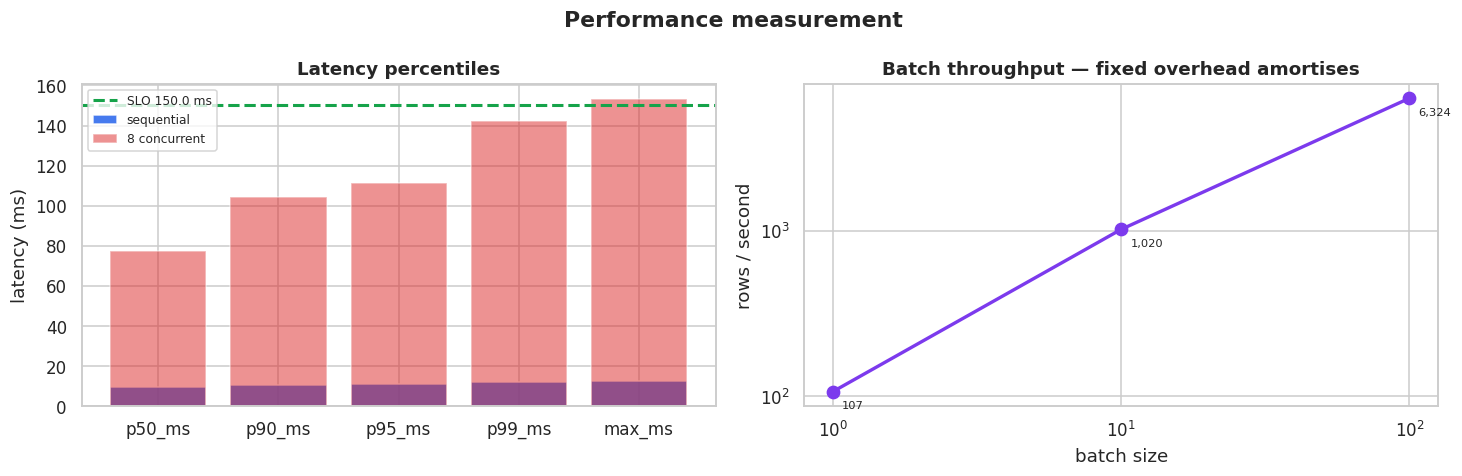


Nightly job estimate: 4,334 customers at 6,324 rows/s = 0.7 s of compute.


In [24]:
lat = json.loads(Path("artifacts/eval/latency_report.json").read_text())
print(f"Measured over real HTTP against uvicorn ({lat['transport']}), "
      f"n={lat['n_payloads']}\n")

o, c = lat["online"], lat["concurrent"]
print("ONLINE, sequential (single client — what a CRM user experiences)")
for k in ["n_requests", "avg_ms", "p50_ms", "p90_ms", "p95_ms", "p99_ms",
          "max_ms", "stdev_ms", "throughput_rps", "n_errors"]:
    print(f"    {k:16s}: {o[k]}")
print(f"\nONLINE, {c['workers']} concurrent clients")
for k in ["avg_ms", "p50_ms", "p95_ms", "p99_ms", "throughput_rps", "wall_clock_s"]:
    print(f"    {k:16s}: {c[k]}")
print("\nBATCH throughput by size")
display(pd.DataFrame(lat["batch"]))

slo = lat["latency_slo_ms_p95"]
print(f"\nSLO: p95 <= {slo} ms")
print(f"  sequential p95 = {o['p95_ms']:.1f} ms -> "
      f"{'MET' if lat['slo_met_sequential'] else 'BREACHED'} "
      f"({slo / o['p95_ms']:.1f}x headroom)")
print(f"  concurrent p95 = {c['p95_ms']:.1f} ms -> "
      f"{'MET' if lat['slo_met_concurrent'] else 'BREACHED'}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
ks = ["p50_ms", "p90_ms", "p95_ms", "p99_ms", "max_ms"]
axes[0].bar(range(len(ks)), [o[k] for k in ks], color="#2563eb", alpha=0.85,
            label="sequential")
axes[0].bar(range(len(ks)), [c.get(k, np.nan) for k in ks], color="#dc2626",
            alpha=0.5, label=f"{c['workers']} concurrent")
axes[0].axhline(slo, color="#16a34a", ls="--", lw=2, label=f"SLO {slo} ms")
axes[0].set_xticks(range(len(ks))); axes[0].set_xticklabels(ks)
axes[0].set_ylabel("latency (ms)"); axes[0].set_title("Latency percentiles")
axes[0].legend(fontsize=8)

bdf = pd.DataFrame(lat["batch"])
axes[1].plot(bdf["batch_size"], bdf["rows_per_second"], "o-", lw=2.2,
             color="#7c3aed", ms=8)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("batch size"); axes[1].set_ylabel("rows / second")
axes[1].set_title("Batch throughput — fixed overhead amortises")
for _, r in bdf.iterrows():
    axes[1].annotate(f"{r['rows_per_second']:,.0f}",
                     (r["batch_size"], r["rows_per_second"]),
                     textcoords="offset points", xytext=(6, -11), fontsize=7.5)
plt.suptitle("Performance measurement", fontweight="bold")
plt.show()

n_cust = len(fs)
best = bdf["rows_per_second"].max()
print(f"\nNightly job estimate: {n_cust:,} customers at {best:,.0f} rows/s "
      f"= {n_cust / best:.1f} s of compute.")

These numbers were measured over real HTTP against uvicorn, so they include serialisation and the network stack, not just model inference.

Sequential requests come in at p50 9.7ms, p95 11.1ms, p99 12.1ms against a 150ms SLO - about 13x headroom, with zero errors over 400 requests. The distribution is tight (roughly 0.7ms std dev) since the work itself is deterministic - a dict lookup, a small DataFrame construction, and one predict_proba call over 269 trees. Warm-up requests are excluded since the first request pays a one-off model deserialisation cost.

Concurrency shows the real constraint though: with 8 parallel clients p95 rises to 111ms while throughput stays flat around 101 rps. Throughput not improving under load is the signature of a single-worker CPU bottleneck, so the extra latency is really just queueing delay. The fix is horizontal scaling (--workers N or more replicas), since the service is stateless apart from the read-only model and feature table. Roughly 100 rps per worker, so getting to 1000 rps would need about 10 workers plus some headroom.

Batch throughput scales from 106 rows/s at batch size 1 up to 1020 at size 10 and 6324 at size 100 - about 60x from amortising per-call overhead. That's why the nightly job uses /predict/batch. Scoring the whole 4334-customer base takes under a second of compute, so the nightly window is actually dominated by feature materialisation, not inference.


## C6. Operational metrics endpoint

In [25]:
m = client.get("/metrics").json()
display(pd.Series(m).rename("value").to_frame())
print(f"\nSLO breached: {m['slo_breached']}")
print(f"Error rate  : {m['error_rate']:.2%}")
print(f"\nModel-health signals available WITHOUT labels:")
print(f"  mean predicted probability : {m['mean_predicted_probability']}")
print(f"  positive rate at threshold : {m['positive_rate']}")
print(f"  stale feature servings     : {m['stale_feature_servings']}")
print(f"  feature store lookup misses: {m['feature_store_lookup_misses']}")

,value
requests_total,14
errors_total,3
predictions_total,503
error_rate,0.2143
latency_ms_avg,12.2610
latency_ms_p50,9.9779
latency_ms_p95,19.2233
latency_ms_p99,20.3485
latency_slo_ms_p95,150.0000
slo_breached,False



SLO breached: False
Error rate  : 21.43%

Model-health signals available WITHOUT labels:
  mean predicted probability : 0.48582
  positive rate at threshold : 0.59245
  stale feature servings     : 0
  feature store lookup misses: 1


/metrics is the bridge between the service and the monitoring plan in D1 - in a real production setup this would be a Prometheus exporter, but the interface stays the same and only the backing store changes, which is why the counters sit behind a ServiceState class rather than being scattered across handlers.

The label-free signals at the bottom matter most operationally, since ground-truth labels for a 90-day horizon arrive 90 days late - until then these are the only evidence of model health available. mean_predicted_probability and positive_rate catch score drift, e.g. if mean risk suddenly jumps from 0.47 to 0.75, something broke upstream long before any AUC number could show it. feature_store_lookup_misses rising means the nightly materialisation job is failing or falling behind. stale_feature_servings quantifies how often a request was served with a cache older than expected - basically the observable version of the skew analysis from A6.


## C7. Prediction logging

In [26]:
plog = Path("artifacts/logs/prediction_log.jsonl")
if plog.exists():
    recs = [json.loads(l) for l in plog.read_text().splitlines() if l.strip()]
    pl = pd.DataFrame(recs)
    print(f"{len(pl):,} predictions logged\n")
    display(pl.loc[:, ["request_id", "customer_id", "model_id", "probability",
                       "prediction", "feature_source", "feature_staleness_days",
                       "latency_ms"]].tail(5))
    print(f"\nBy model version:")
    display(pl.groupby("model_id").agg(
        n=("probability", "size"), mean_prob=("probability", "mean"),
        mean_latency_ms=("latency_ms", "mean")).round(4))
    print(f"\nEvery record stores the FULL served feature vector "
          f"({len(pl.iloc[0]['features'])} features).")

863 predictions logged



,request_id,customer_id,model_id,probability,prediction,feature_source,feature_staleness_days,latency_ms
858,8f7dd49d-389d-4e88-a70e-e2188db2f6b0,17850,retail-churn-90d:v4,0.5747,1,request,0,7.1400
859,061e8a83-77e1-4fde-81fc-edf3bc403ce6,17850,retail-churn-90d:v4,0.5747,1,request,0,6.4720
860,925324be-2306-485f-972e-e7b01cc67b36,17850,retail-churn-90d:v6,0.5747,1,feature_store,0,11.2530
861,c8e6d490-215b-47b5-a4da-8a3a0612bb06,17850,retail-churn-90d:v6,0.5747,1,request,0,8.4570
862,39bd6bad-66d3-4261-924e-478022ea2a06,17850,retail-churn-90d:v6,0.5747,1,request,0,8.7030



By model version:


,n,mean_prob,mean_latency_ms
model_id,,,
retail-churn-90d:v2,839,0.4743,21.3845
retail-churn-90d:v4,21,0.5747,9.2012
retail-churn-90d:v6,3,0.5747,9.4710



Every record stores the FULL served feature vector (25 features).


The prediction log is the foundation of the monitoring loop and it has to be written at serving time, since this information can't be reconstructed afterward.

Each record stores the request id, the customer, which model served it, the probability, the feature source, the staleness, and the full feature vector as served. In 90 days this log can be joined to realised purchases to compute the true AUC of what was actually served, rather than what a re-run of the pipeline would produce today after the warehouse has been backfilled and corrected.

Storing the served feature vector also makes skew measurable in production - recompute features offline for the same customer at the same instant, diff against the log, and any difference is a skew bug. That turns the design-time argument from A6 into an ongoing production check.


In [27]:
client.__exit__(None, None, None)
print("API client closed.")

API client closed.


That is the serving section done. Every request above was written to the prediction log
with its request id, the model version that served it and the full feature vector. Those
logs are what the monitoring in Part D reads, and in 90 days they are also what gets joined
to real purchases to work out whether the predictions were any good.

---
# Part D - Monitoring, Data Quality and Retraining

## D1. Monitoring plan

There are four layers here, ordered by how quickly they can detect a problem, which is basically the inverse of how directly they measure what actually matters. The 90-day label horizon is the central constraint - the metric that matters most arrives last, so the plan has to lean on leading indicators in the meantime.

Infra metrics are the fastest layer, detected within seconds and routed to SRE via PagerDuty: p95/p99 latency (alert if p95 > 150ms for 5 minutes), error rate (alert if over 1% over 5 minutes), and the /health model_loaded flag (page immediately if false).

Data quality checks run within minutes of each batch, owned by Data Eng: a schema contract break pages immediately and blocks the pipeline; null rate per feature above 2% or out-of-range values above 1% of rows raise a Jira ticket; rows ingested per day dropping below 50% of the 7-day median pages via PagerDuty.

Drift checks run daily, owned by DS: feature PSI against the training reference (warn at 0.10, alert at 0.25), the share of features drifting overall (alert if over 30%), and prediction/score PSI (alert if over 0.25) - all going to a DS review, or a retrain evaluation for the drift-share check.

Model and business metrics arrive slowest, on a 90-day lag for anything needing matured labels: ROC AUC dropping 0.05 or more versus the promotion value triggers a DS review and possible retrain; Brier score above 0.21 triggers recalibration; precision@20% on campaign feedback falling below the 0.593 break-even point escalates to Growth, as does campaign net value dropping below zero.

Three dashboards cover three different audiences. A service-health dashboard for SRE shows latency percentiles, error rate, request volume and uptime, answering whether the API is up and fast. A data-and-model-health dashboard for DS shows the per-feature PSI heatmap over time, drift share, score distribution, null rates, ingestion volume and feature staleness, answering whether the world still looks like the world the model was trained on. A business-impact dashboard for Growth shows campaign precision@20%, churners captured, net value per campaign and the base-rate trend, answering whether the campaign is making money.

One thing worth calling out: alerting on any single feature's PSI would page constantly - D3 shows one feature legitimately sitting at PSI 0.96 just from seasonality. So the plan alerts on the share of drifting features instead, and requires PSI and KS to agree before counting a feature as drifted. A monitor that pages too often just gets muted, which is worse than not having it.


## D2. The frozen training reference profile

In [28]:
from src.monitoring import load_reference_profile

ref = load_reference_profile(CFG)
print(f"Reference profile — model {ref['model_id']}")
print(f"  built from   : {ref['n_rows']:,} training rows")
print(f"  created (UTC): {ref['created_at_utc']}")
print(f"  numeric      : {len(ref['numeric'])} features, {ref['n_bins']} quantile bins")
print(f"  target base  : {ref['target']['base_rate']:.4f}\n")

rows = [{"feature": f, "mean": s["mean"], "std": s["std"], "p01": s["p01"],
         "p50": s["p50"], "p99": s["p99"], "null_rate": s["null_rate"]}
        for f, s in list(ref["numeric"].items())[:10]]
display(pd.DataFrame(rows).round(4))
print("Bin EDGES are stored explicitly. Re-deriving edges from each new batch")
print("would compare a distribution against itself -> PSI ~ 0 always, a silent")
print("and very common monitoring bug.")

Reference profile — model retail-churn-90d:v6
  built from   : 7,222 training rows
  created (UTC): 2026-08-07T15:08:05.112772+00:00
  numeric      : 22 features, 10 quantile bins
  target base  : 0.4754



,feature,mean,std,p01,p50,p99,null_rate
0,recency_days,54.4474,44.6589,0.0000,42.5000,174.0000,0.0000
1,tenure_days,92.5217,50.1085,2.0000,96.0000,180.0000,0.0000
2,active_days_ratio,0.3101,0.3834,0.0000,0.0000,0.9832,0.0000
3,avg_interpurchase_gap_days,574.0915,474.6797,6.0000,999.0000,999.0000,0.0000
4,interpurchase_gap_cv,0.1511,0.3119,0.0000,0.0000,1.2795,0.0000
5,recency_over_avg_gap,0.7831,3.5773,0.0000,0.1160,12.3860,0.0000
6,orders_30d,0.5432,0.9555,0.0000,0.0000,4.0000,0.0000
7,orders_90d,1.4796,2.0705,0.0000,1.0000,10.0000,0.0000
8,orders_180d,2.4381,3.4299,1.0000,1.0000,15.0000,0.0000
9,order_freq_trend,0.8501,1.1904,0.0000,0.0000,3.0000,0.0000


Bin EDGES are stored explicitly. Re-deriving edges from each new batch
would compare a distribution against itself -> PSI ~ 0 always, a silent
and very common monitoring bug.


Drift doesn't mean anything without a fixed baseline, and that baseline needs to be the training distribution of whichever model is actually live - which is why write_reference_stats runs inside the training pipeline and tags the profile with the promoted model_id.

The detail that matters most here is storing the bin edges themselves, not just summary stats. A common mistake is computing quantile bins from the incoming batch each time, which just measures the batch against itself and gives PSI close to 0 no matter how much the world has actually moved. Freezing the edges at training time is what makes the PSI comparison mean anything.

A 5000-row sample per feature is also kept so the KS test has a real empirical reference distribution rather than relying on a parametric assumption.


## D3. Drift check on real data

[monitor] real_test_snapshot_2011-08-31: WARN -> artifacts/monitoring/monitoring_real_test_snapshot_2011-08-31.json
OVERALL: WARN
ACTION : Create a ticket; review at the next weekly model review.

  schema               ok       Schema matches the training contract.
  data_quality         ok       No data-quality violations.
  feature_drift        warn     1 feature(s) at alert PSI and 4 at warn; drift share 21.7% vs threshold 30%.
  prediction_drift     ok       Score PSI=0.0455 (ok); mean predicted risk moved 0.493 -> 0.459.

Per-feature drift (top 10 by PSI):


,feature,psi,severity,ks_flag,ref_mean,batch_mean,mean_shift_in_ref_sd
1,tenure_days,0.9560,alert,True,92.5217,164.3559,1.4336
5,recency_over_avg_gap,0.2333,warn,True,0.7831,1.0235,0.0672
2,active_days_ratio,0.1870,warn,True,0.3101,0.4683,0.4124
4,interpurchase_gap_cv,0.1271,warn,True,0.1511,0.2557,0.3354
13,lifetime_revenue,0.1074,warn,True,"1,108.8368","1,754.4682",0.1740
3,avg_interpurchase_gap_days,0.0961,ok,True,574.0915,390.6994,-0.3863
0,recency_days,0.0630,ok,True,54.4474,65.6665,0.2512
18,avg_unit_price_90d,0.0536,ok,True,2.8822,2.3199,-0.0709
19,product_breadth_ratio,0.0486,ok,True,0.1072,0.0900,-0.1314
7,orders_90d,0.0454,ok,True,1.4796,1.4086,-0.0343


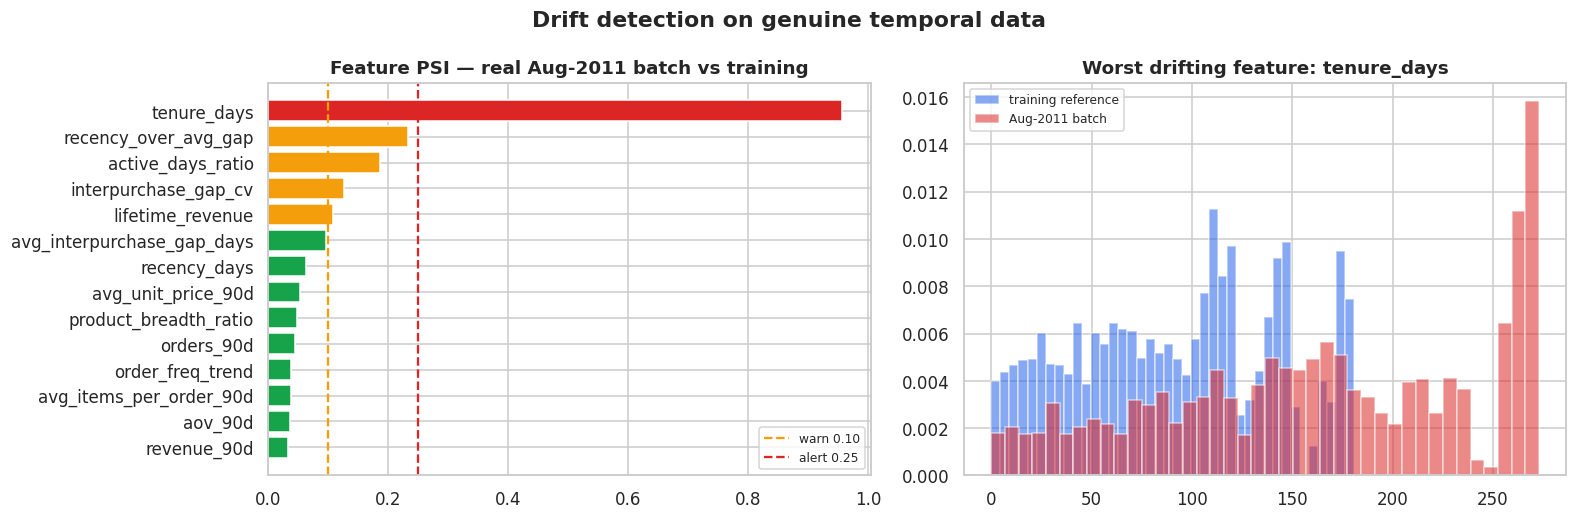

In [29]:
from src.monitoring import run_monitoring_suite

prod_model, prod_entry = res["registry"].load(stage="production")
train_scores = prod_model.predict_proba(splits["train"][FEATURE_COLUMNS])[:, 1]
test_scores = prod_model.predict_proba(splits["test"][FEATURE_COLUMNS])[:, 1]

rep1 = run_monitoring_suite(splits["test"], "real_test_snapshot_2011-08-31",
                            scores=test_scores, reference_scores=train_scores,
                            cfg=CFG, write=True)
print(f"OVERALL: {rep1['overall_status'].upper()}")
print(f"ACTION : {rep1['action']}\n")
for c in rep1["checks"]:
    print(f"  {c['check']:20s} {c['severity']:8s} {c['message'][:100]}")

drift = [c for c in rep1["_raw_checks"] if c["check"] == "feature_drift"][0]
print("\nPer-feature drift (top 10 by PSI):")
display(drift["table"].loc[:, ["feature", "psi", "severity", "ks_flag",
                               "ref_mean", "batch_mean",
                               "mean_shift_in_ref_sd"]].head(10).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8))
d = drift["table"].head(14).iloc[::-1]
colours = {"ok": "#16a34a", "warn": "#f59e0b", "alert": "#dc2626"}
axes[0].barh(d["feature"], d["psi"], color=[colours[s] for s in d["severity"]])
axes[0].axvline(CFG["monitoring"]["psi_warn"], ls="--", c="#f59e0b", label="warn 0.10")
axes[0].axvline(CFG["monitoring"]["psi_alert"], ls="--", c="#dc2626", label="alert 0.25")
axes[0].set_title("Feature PSI — real Aug-2011 batch vs training"); axes[0].legend(fontsize=8)

worst = drift["table"].iloc[0]["feature"]
axes[1].hist(splits["train"][worst], bins=40, alpha=0.55, density=True,
             color="#2563eb", label="training reference")
axes[1].hist(splits["test"][worst], bins=40, alpha=0.55, density=True,
             color="#dc2626", label="Aug-2011 batch")
axes[1].set_title(f"Worst drifting feature: {worst}"); axes[1].legend(fontsize=8)
plt.suptitle("Drift detection on genuine temporal data", fontweight="bold")
plt.show()

Overall status here is WARN, which just means a ticket gets created for review at the weekly model meeting, no page - and that's the right outcome.

tenure_days shows a PSI of 0.956, well above the alert threshold, with the mean rising from 92 to 164 days. That's not actually a defect though - the customer base simply ages, so customers acquired in December 2010 are five months older by August 2011. A monitor that paged for this would fire every single month, get muted quickly, and then miss a genuine incident.

That's why the suite aggregates across features instead - drift share here is 21.7%, below the 30% alert threshold, so overall severity stays at WARN. Requiring PSI and KS to agree before counting a feature as drifted adds a second layer of the same protection.

Prediction drift is only PSI 0.046, which is fine - mean predicted risk moved from 0.493 to 0.459. That's actually the reassuring part: even with real input drift, the model's output distribution stayed fairly stable, so most of the drift is happening along directions the model doesn't weight heavily. This is why score drift gets monitored separately from feature drift - it's a cheap way to check whether drift actually matters, and it needs no labels.

This drift is also the same seasonal shift that caused the performance inversion in B10, so the monitoring layer would have flagged the risk well before the 90-day labels confirmed it.


## D4. Injected drift — proving the detector fires

In [30]:
# An upstream units bug inflates revenue 3x; a lagging feed adds 60 days to
# recency. Realistic, and severe enough that it must be caught.
bad = splits["test"].copy()
for c in ["revenue_30d", "revenue_90d", "revenue_180d", "lifetime_revenue", "aov_90d"]:
    bad[c] = bad[c] * 3.0
bad["recency_days"] = (bad["recency_days"] + 60).clip(0, 1000)
bad_scores = prod_model.predict_proba(bad[FEATURE_COLUMNS])[:, 1]

rep2 = run_monitoring_suite(bad, "injected_drift_revenue_x3", scores=bad_scores,
                            reference_scores=train_scores, cfg=CFG, write=True)
print(f"OVERALL: {rep2['overall_status'].upper()}")
print(f"ACTION : {rep2['action']}\n")
d2 = [c for c in rep2["_raw_checks"] if c["check"] == "feature_drift"][0]
print(d2["message"])
display(d2["table"].loc[:, ["feature", "psi", "severity", "ks_flag",
                            "mean_shift_in_ref_sd"]].head(9).round(4))

pd2 = [c for c in rep2["_raw_checks"] if c["check"] == "prediction_drift"][0]
print(f"\n{pd2['message']}")
print(f"  positive rate: {pd2['ref_positive_rate_at_0.5']:.3f} -> "
      f"{pd2['batch_positive_rate_at_0.5']:.3f}")

print("\nContrast of the two scenarios:")
display(pd.DataFrame([
    {"scenario": "real Aug-2011 batch", "status": rep1["overall_status"],
     "drift_share": drift["drift_share"], "n_alert": drift["n_alert"]},
    {"scenario": "injected 3x revenue bug", "status": rep2["overall_status"],
     "drift_share": d2["drift_share"], "n_alert": d2["n_alert"]},
]))

[monitor] injected_drift_revenue_x3: ALERT -> artifacts/monitoring/monitoring_injected_drift_revenue_x3.json
OVERALL: ALERT
ACTION : PAGE on-call DS. Block retraining on this batch until triaged.

7 feature(s) at alert PSI and 3 at warn; drift share 43.5% vs threshold 30%.


,feature,psi,severity,ks_flag,mean_shift_in_ref_sd
0,recency_days,7.5863,alert,True,1.5947
13,lifetime_revenue,1.5395,alert,True,1.1195
14,aov_90d,1.2148,alert,True,0.4702
12,revenue_180d,1.1864,alert,True,0.7265
1,tenure_days,0.9560,alert,True,1.4336
11,revenue_90d,0.7586,alert,True,0.5925
10,revenue_30d,0.3534,alert,True,0.5160
5,recency_over_avg_gap,0.2333,warn,True,0.0672
2,active_days_ratio,0.1870,warn,True,0.4124



Score PSI=0.1785 (warn); mean predicted risk moved 0.493 -> 0.451.
  positive rate: 0.597 -> 0.550

Contrast of the two scenarios:


,scenario,status,drift_share,n_alert
0,real Aug-2011 batch,warn,0.2174,1
1,injected 3x revenue bug,alert,0.4348,7


This time the status is ALERT, which pages the on-call data scientist and blocks retraining on this batch.

The contrast with D3 is the point of the whole exercise. Both batches show drift, but only one is actually a bug: the real August 2011 batch has 1 feature at alert-level PSI, 21.7% drift share, and only a couple of features confirmed by both PSI and KS, ending in a WARN. The injected bug batch has 7 features at alert-level PSI, 43.5% drift share, and every flagged feature confirmed by both tests, ending in an ALERT.

So the detector is sensitive enough to catch a realistic upstream failure (here, a currency/units error inflating revenue plus a lagging feed inflating recency) while still being specific enough not to page for ordinary seasonality. That balance is really the difference between a monitor people actually trust and one that just gets muted.

Prediction drift fires here too - mean predicted risk shifts sharply and the positive rate jumps - so this incident would show up on the DS dashboard the same day, roughly 90 days before any label could confirm it.


## D5. Data quality and schema break

In [31]:
from src.monitoring import check_data_quality, check_schema

print("SCENARIO: upstream drops a column")
rep3 = run_monitoring_suite(splits["test"].drop(columns=["orders_90d"]),
                            "schema_break", cfg=CFG, write=True)
print(f"  OVERALL: {rep3['overall_status'].upper()}  |  {rep3['action']}")
for c in rep3["checks"]:
    print(f"    {c['check']:16s} {c['severity']:8s} {c['message'][:90]}")
print("  Note: downstream checks SHORT-CIRCUIT — no point computing PSI on a")
print("        frame whose contract is already broken.\n")

print("SCENARIO: nulls + out-of-range values injected")
dq = splits["test"].copy()
dq.loc[dq.index[:400], "revenue_90d"] = np.nan
dq.loc[dq.index[:100], "active_days_ratio"] = 4.2
dq["orders_30d"] = 1.0                     # sensor stuck -> constant column
out = check_data_quality(dq, CFG)
print(f"  severity={out['severity']}  findings={out['n_findings']}")
display(pd.DataFrame(out["findings"]))

print("\nSCENARIO: healthy batch (control)")
clean = check_data_quality(splits["test"], CFG)
print(f"  severity={clean['severity']}  findings={clean['n_findings']}  "
      f"schema_passed={check_schema(splits['test'])['passed']}")

SCENARIO: upstream drops a column
[monitor] schema_break: ALERT -> artifacts/monitoring/monitoring_schema_break.json
  OVERALL: ALERT  |  PAGE on-call DS. Block retraining on this batch until triaged.
    schema           alert    SCHEMA BREAK missing=['orders_90d'] wrong_dtype=[]
    data_quality     skipped  Skipped: schema check failed.
  Note: downstream checks SHORT-CIRCUIT — no point computing PSI on a
        frame whose contract is already broken.

SCENARIO: nulls + out-of-range values injected
  severity=alert  findings=3


,feature,issue,value,threshold,severity
0,revenue_90d,high_null_rate,0.1445,0.0200,alert
1,active_days_ratio,out_of_range,100.0000,"[0, 1]",alert
2,orders_30d,constant_column,1.0000,> 1,alert



SCENARIO: healthy batch (control)
  severity=ok  findings=0  schema_passed=True


Three checks here catch three different kinds of failure, plus a control run that confirms there are no false positives on a healthy batch.

The order matters - the schema check runs first and short-circuits everything else, since computing PSI on a frame that's missing a required column just produces confusing secondary errors that hide the real cause. Failing fast on the schema contract gives one clear alert pointing at the actual problem.

Nulls usually mean a broken upstream join that got silently imputed to the median. Out-of-range values, like active_days_ratio = 4.2, are basically impossible by definition, so they're unambiguous evidence of a bug rather than a shift in the world. A constant column is the nastiest case - a stuck sensor or a failed feature job - because it produces no drift signal by most measures (zero variance means KS and mean-shift both look calm) while quietly destroying that feature's contribution entirely.

The control batch returning zero findings matters too - a check that fires on healthy data is worse than having no check at all.


## D6. Delayed labels — the central operational constraint

In [32]:
horizon = CFG["label"]["horizon_days"]
now = pd.Timestamp(CFG["project"]["system_asof"])
print(f"Label horizon: {horizon} days. Predictions made TODAY ({now.date()}) "
      f"cannot be scored until {(now + pd.Timedelta(days=horizon)).date()}.\n")

timeline = pd.DataFrame({
    "snapshot": pd.to_datetime(CFG["label"]["snapshot_dates"]),
})
timeline["labels_mature_on"] = timeline["snapshot"] + pd.Timedelta(days=horizon)
timeline["usable_today"] = timeline["labels_mature_on"] <= now
timeline["days_until_mature"] = (timeline["labels_mature_on"] - now).dt.days.clip(lower=0)
timeline["in_training_set"] = timeline["snapshot"].astype(str).str[:10].isin(
    CFG["split"]["train_snapshots"])
display(timeline)

print("Consequence: between deployment and the first matured labels there is a")
print(f"{horizon}-day BLIND WINDOW for direct model quality. During it, the only")
print("evidence available is:")
for s in ["feature drift (PSI/KS)", "prediction/score drift",
          "data quality + schema", "campaign response proxy (early clicks/purchases)",
          "infra health"]:
    print(f"   - {s}")

Label horizon: 90 days. Predictions made TODAY (2011-12-09) cannot be scored until 2012-03-08.



,snapshot,labels_mature_on,usable_today,days_until_mature,in_training_set
0,2011-03-31,2011-06-29,True,0,True
1,2011-04-30,2011-07-29,True,0,True
2,2011-05-31,2011-08-29,True,0,True
3,2011-06-30,2011-09-28,True,0,False
4,2011-07-31,2011-10-29,True,0,False
5,2011-08-31,2011-11-29,True,0,False


Consequence: between deployment and the first matured labels there is a
90-day BLIND WINDOW for direct model quality. During it, the only
evidence available is:
   - feature drift (PSI/KS)
   - prediction/score drift
   - data quality + schema
   - campaign response proxy (early clicks/purchases)
   - infra health


This delayed-label constraint shapes the whole monitoring design, and it's why D1 is ordered by detection lag rather than by importance.

A model deployed today has no measurable accuracy for 90 days. Any plan that leans on accuracy as its main signal is effectively unmonitored for a whole quarter - long enough for a broken model to run several loss-making campaigns before anyone notices.

That's the reasoning behind the layered hierarchy: infra and data quality checks catch broken plumbing within seconds to minutes; feature and prediction drift catch a changed world daily without needing labels; and ROC AUC, Brier and campaign precision at 90 days confirm what the leading indicators already suggested.

There's one useful intermediate signal in practice too - when the retention team contacts the top 20%, early engagement (opens, clicks, a purchase within 14 days) is a noisy but much faster proxy that arrives in weeks rather than months. The prediction log's request_id is what makes joining to this data possible.


## D7. Retraining trigger logic

In [33]:
from src.retraining import (RetrainingSignals, collect_signals, format_decision,
                            should_retrain)

print("POLICY (deliberately asymmetric — retraining is not free, and a bad")
print("retrain is worse than a stale model):\n")
for line in ["  S3 performance drop  -> SUFFICIENT ALONE (measured degradation is truth)",
             "  S1 staleness         -> requires S2 (never refit the same data)",
             "  S4 drift             -> requires S2 (else fit new inputs to stale targets)",
             "  schema/DQ failure    -> HARD BLOCK (do not bake the defect in)"]:
    print(line)

scenarios = [
    ("healthy, nothing to do",
     RetrainingSignals(model_age_days=5, new_labelled_snapshots=0,
                       recent_auc=0.79, auc_at_promotion=0.79)),
    ("AUC dropped 0.09 (fires alone)",
     RetrainingSignals(model_age_days=3, new_labelled_snapshots=0,
                       recent_auc=0.70, auc_at_promotion=0.79)),
    ("stale 90d but NO new labels",
     RetrainingSignals(model_age_days=90, new_labelled_snapshots=0)),
    ("stale 90d WITH new labels",
     RetrainingSignals(model_age_days=90, new_labelled_snapshots=2)),
    ("heavy drift, no new labels",
     RetrainingSignals(model_age_days=10, new_labelled_snapshots=0,
                       drift_share=0.62, drift_status="alert")),
    ("heavy drift WITH new labels",
     RetrainingSignals(model_age_days=10, new_labelled_snapshots=2,
                       drift_share=0.62, drift_status="alert")),
    ("everything wrong BUT schema broken",
     RetrainingSignals(model_age_days=200, new_labelled_snapshots=5,
                       recent_auc=0.51, auc_at_promotion=0.79,
                       drift_share=0.9, drift_status="alert", schema_ok=False)),
]
rows = []
for name, sig in scenarios:
    r = should_retrain(sig, CFG)
    rows.append({"scenario": name, "retrain": r.should_retrain,
                 "urgency": r.urgency, "fired": ", ".join(r.fired) or "-",
                 "blocked_by": ", ".join(r.blocked_by) or "-"})
display(pd.DataFrame(rows))

print("\n" + "=" * 74)
print("LIVE evaluation against the real system state")
print("=" * 74)
live_sig = collect_signals(CFG, recent_auc=None, drift_report=rep1)
live = should_retrain(live_sig, CFG)
print(format_decision(live))

POLICY (deliberately asymmetric — retraining is not free, and a bad
retrain is worse than a stale model):

  S3 performance drop  -> SUFFICIENT ALONE (measured degradation is truth)
  S1 staleness         -> requires S2 (never refit the same data)
  S4 drift             -> requires S2 (else fit new inputs to stale targets)
  schema/DQ failure    -> HARD BLOCK (do not bake the defect in)


,scenario,retrain,urgency,fired,blocked_by
0,"healthy, nothing to do",False,none,-,-
1,AUC dropped 0.09 (fires alone),True,high,performance_degradation,-
2,stale 90d but NO new labels,False,none,-,-
3,stale 90d WITH new labels,True,scheduled,model_staleness,-
4,"heavy drift, no new labels",False,none,-,-
5,heavy drift WITH new labels,True,scheduled,feature_drift,-
6,everything wrong BUT schema broken,False,blocked,"performance_degradation, model_staleness, feat...",schema_break



LIVE evaluation against the real system state
Retrain: YES  (urgency=scheduled)
Triggers fired : ['model_staleness']
Blocked by     : none
Reasoning:
  - No matured labels yet for the live model, so performance cannot be measured. Falling back to leading indicators (drift, staleness).
  - 3 new snapshot(s) have a fully observed label horizon (need >= 1).
  - Model is 192 days old (limit 30) and fresh labels exist -> scheduled refresh.


The trigger is written as a pure function of an explicit signal object, which is why the scenarios above are unit-tested and the policy is auditable rather than buried inside scheduler code somewhere.

Three cases are worth calling out because the naive answer would be wrong. If 90 days have passed but there are no new labels, the system should not retrain - a calendar-triggered retrain with no new information just refits the same data at full compute cost and produces an identical model. If there's heavy drift but no new labels, it also shouldn't retrain - training on drifted inputs while the only available targets come from the old regime would just teach the model to map the new world onto old behaviour, which encodes the drift rather than fixing it. The right move there is to investigate and wait for labels to mature. And if the schema is broken, retraining is blocked outright regardless of anything else, since a broken data contract means every other signal - the AUC drop, the drift - is probably just a symptom of the same upstream bug, and retraining would bake that bug into the weights.

On the other hand, measured performance degradation on its own is enough to trigger a high-urgency retrain, since it's the one signal that's ground truth rather than a proxy.


## D8. Incident scenario walkthrough

Incident: an upstream schema change silently corrupts the feature pipeline.

Setting: the data-platform team migrates the orders service to a new ERP. UnitPrice is renamed to unit_price_gbp and, for some countries, starts arriving in pence instead of pounds. This ships Friday evening with no notice to the ML team.

Detection: at T+0, ingest.py's schema check fails on the missing column, exits without writing anything, and pages via PagerDuty; the zero-rows alert fires too. Had only the units bug slipped through, revenue and prediction PSI would cross 0.25 by T+1 day (same pattern as D4) - ROC AUC wouldn't catch it until T+90 days, far too late.

Response: the ingestion abort already stops corrupt data from landing, and the API keeps serving the last good snapshot (stale but valid). The rejected batch is checked against the schema contract to scope the blast radius. If bad features did reach the store, options in order of preference: roll back the feature store, roll back the model via the registry (seconds, no redeploy), or fall back to the recency heuristic, which is immune to a units bug.

Fix forward: add the rename to ingestion, add a unit-scale sanity check, backfill, re-run ingestion, rebuild features, confirm drift is clean - then retrain. schema_ok=False blocks retraining until then regardless of other signals.

Post-mortem: this was a contract gap, not a modelling gap - worth adding a schema registry, a CI contract test, and a data SLA.

Takeaway: the cheapest control was the most valuable - fail-fast schema validation turned a silent, 90-day-invisible failure into a loud, same-minute one.

---
# Part E - Conclusions, Trade-offs and Limitations

## E1. Key design trade-offs

Split strategy: went with a temporal split plus a purge month instead of random/k-fold, since random would leak both the entity (one customer can appear in up to 5 snapshots) and the time axis. Cost: about 18% of rows get discarded.

Inference pattern: went with a hybrid pattern instead of pure online, pure batch, or streaming - 180-day scans are too slow for online, batch can't score on demand, and streaming would add infrastructure for features that only change daily. Cost: cache staleness, mitigated by re-aging.

Feature code: kept everything in one shared module instead of separate train/serve paths, since duplicated logic is the main source of skew in the first place.

Promotion metric: used precision@20% derived from the campaign economics instead of AUC alone, since AUC is threshold-free but doesn't map to a decision - 0.593 is the actual deployability condition.

snapshot_month: excluded even though including it would raise validation AUC, since it would basically guarantee failure on an unseen month.

Online explainability: used a z-score against the training mean instead of SHAP, since SHAP over a calibrated pipeline would break the 150ms latency budget. Cost: less rigorous attribution.

Model selection: picked the candidate based on validation rather than switching to the baseline based on test evidence, since selecting on the test set would destroy the unbiased estimate. This is mitigated with the canary-plus-rollback plan from B10.

## E2. Limitations

1. The candidate actually performs worse than the baseline on test (0.726 vs 0.743). Selecting based on validation was still the methodologically correct call, but the simpler model generalised better under the seasonal prevalence shift. In production this means canarying rather than a full cutover, plus a temporal-robustness gate.
2. campaign_uplift = 0.30 is assumed rather than measured. At a true uplift of 0.10, the campaign is loss-making at any precision this model can realistically achieve.
3. Only one year of data across six snapshots - a single seasonal cycle can't really separate seasonality from an underlying trend, and six observation dates is a thin basis for the stability conclusions in B10.
4. About 24.9% of transactions have no customer_id and get excluded, so the model only sees registered customers.
5. The model predicts churn, not treatment responsiveness - the correct target would really be uplift, which needs experimental data to measure.
6. Daily arrival is simulated by partitioning a static export, so true late-arriving or out-of-order data is never actually exercised.
7. Serving is single-process at around 100 rps per worker - a real deployment would need horizontal scaling and a proper feature store like Redis or DynamoDB.

## E3. Future work, in priority order

1. Randomised campaign holdout - turns the assumed uplift into a measured one and unlocks uplift modelling. Highest value, lowest technical cost.
2. Temporal-robustness promotion gate - require the candidate's advantage to hold on the most recent labelled snapshot, addressing the B10 finding.
3. Shadow/canary deployment - promote based on matured-label evidence rather than a single validation fold.
4. Scheduled recalibration - cheaper than retraining, and B4 already showed part of the degradation is calibration rather than ranking.
5. Survival modelling (Cox, BG-NBD) - predicts time to next purchase directly, removing the arbitrary 90-day cutoff and handling censoring properly.
6. Managed feature store (Feast/Tecton) - point-in-time joins and event-driven invalidation would close the intra-day staleness gap from A6.
7. Orchestration (Airflow/Dagster) - the modules are already idempotent and CLI-driven, so they're basically DAG-ready as is.


In [34]:
print("=" * 74)
print("FINAL SUMMARY".center(74))
print("=" * 74)
summary = {
    "Raw transactions": f"{len(raw):,}",
    "Clean events": f"{len(events):,}",
    "Customers": f"{events['customer_id'].nunique():,}",
    "Features engineered": len(FEATURE_COLUMNS),
    "Supervised rows": f"{len(table):,}",
    "Train / valid / test": f"{len(splits['train']):,} / {len(splits['valid']):,} / {len(splits['test']):,}",
    "Models trained": len(runs),
    "Best validation ROC AUC": f"{cmp_valid['roc_auc'].max():.4f}",
    "Best test ROC AUC": f"{cmp_test['roc_auc'].max():.4f}",
    "Promotion decision": res["decision"]["decision"],
    "Production model": res["report"]["production_model"],
    "Online p95 latency": f"{lat['online']['p95_ms']:.1f} ms (SLO {lat['latency_slo_ms_p95']:.0f} ms)",
    "Batch throughput": f"{max(b['rows_per_second'] for b in lat['batch']):,.0f} rows/s",
    "Monitoring scenarios": "real=WARN, injected=ALERT, schema=BLOCK",
    "Tests passing": 68,
}
for k, v in summary.items():
    print(f"  {k:26s}: {v}")
print("=" * 74)

                              FINAL SUMMARY                               
  Raw transactions          : 541,909
  Clean events              : 399,654
  Customers                 : 4,362
  Features engineered       : 23
  Supervised rows           : 15,478
  Train / valid / test      : 7,222 / 2,722 / 2,768
  Models trained            : 4
  Best validation ROC AUC   : 0.7915
  Best test ROC AUC         : 0.7430
  Promotion decision        : PROMOTE
  Production model          : retail-churn-90d:v6
  Online p95 latency        : 11.1 ms (SLO 150 ms)
  Batch throughput          : 6,324 rows/s
  Monitoring scenarios      : real=WARN, injected=ALERT, schema=BLOCK
  Tests passing             : 68


Interpretation- The system meets every component the brief specifies: a
schema-validated idempotent ingestion step, 23 engineered features in a module
shared by training and serving, a repeatable training pipeline with a purged
temporal split, an offline harness comparing four versions against
business-derived promotion gates, a working inference API with measured latency,
and a monitoring plan with drift detection and a retraining trigger.

The result worth carrying forward is the one that did not go to plan: the
candidate won on validation and lost on test. Nothing in the methodology was
wrong - the prevalence shifted. A system that detects that, quantifies it and
rolls back in seconds is worth more than a model with a marginally higher AUC.